**Analyse et modélisation du dataset FAO (Food and agriculture Organization).**

# SETUP

## IMPORTS

### Standards

In [301]:
import os
import warnings
from pathlib import Path

### Externals

In [302]:
# Data
import numpy as np
import pandas as pd

# Viz
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyBboxPatch
import plotly.graph_objects as go
import plotly.express as px


# ML
import sklearn as sk
from sklearn import (
    compose,
    cluster,
    dummy,
    decomposition,
    ensemble,
    linear_model,
    metrics,
    model_selection,
    pipeline,
    preprocessing,
)
import xgboost as xgb

# Other

from tqdm import TqdmExperimentalWarning

warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

from tqdm_joblib import tqdm_joblib
from IPython.display import display


## OPTIONS

### Warnings

In [303]:
warnings.filterwarnings("ignore")

### Pandas

In [304]:
pd.options.display.max_rows = None
pd.options.display.max_columns = None

### Matplotlib

In [305]:
PALETTE = [
    "#2ecc71",
    "#3498db",
    "#e74c3c",
    "#f39c12",
    "#9b59b6",
    "#1abc9c",
    "#e67e22",
    "#34495e",
    "#e91e63",
    "#00bcd4",
]
BG_COLOR = "#0f1117"
CARD_COLOR = "#1a1d27"
TEXT_COLOR = "#edf2f7"
ACCENT = "#2ecc71"

plt.rcParams.update(
    {
        "figure.facecolor": BG_COLOR,  # Couleur de fond globale.
        "axes.facecolor": CARD_COLOR,  # Couleur de fond du graphique.
        "axes.edgecolor": "#2d3748",  # Couleur des bordures.
        "axes.labelcolor": TEXT_COLOR,  # Couleur des titres des axes X/Y.
        "axes.titlecolor": TEXT_COLOR,  # Couleur du titre du graphique.
        "xtick.color": TEXT_COLOR,  # Couleur des valeurs sur l"axe X.
        "ytick.color": TEXT_COLOR,  # Couleur des valeurs sur l"axe Y.
        "text.color": TEXT_COLOR,  # Couleur par defaut des textes.
        "grid.color": "#2d3748",  # Couleur de la grille.
        "grid.linestyle": "--",  # Grille en pointilles.
        "grid.alpha": 0.5,  # Grille semi-transparente.
        "font.family": "Arial",  # Police d"ecriture utilisee.
        "axes.spines.top": False,  # Masque la bordure superieure.
        "axes.spines.right": False,  # Masque la bordure droite.
    }
)

### Sklearn

In [306]:
sk.set_config(transform_output="pandas")

## CONFIGS

### Seeds

In [307]:
RANDOM = 42
np.random.seed(RANDOM)

### Folders

In [308]:
ROOT = Path("../")
DATA = ROOT / "data"
CACHE = ROOT / ".cache"
PLOTS = ROOT / "notebooks" / "plots"

### Datasets

In [309]:
YIELD_GEN = DATA / "crop_yield.csv"

FAO = DATA / "Crop Yield Prediction Dataset"

PESTICIDES = FAO / "pesticides.csv"
RAINFALL = FAO / "rainfall.csv"
TEMPERATURE = FAO / "temp.csv"
YIELD = FAO / "yield.csv"
YIELD_FAO = FAO / "yield_df.csv"

CSV_FILES = sorted(DATA.rglob("*.csv"))

### Columns

In [310]:
TARGET = "yield"

### Sampling

In [311]:
RAW_NROWS = None  # set an integer for faster iterations, e.g. 100_000.
SAMPLE_ROWS = 100_000

### Splittings

In [312]:
SPLITS = 4
SHUFFLE = False  # required (time sensitive).
TEST_YEAR_START = 2010

### Searchings

In [313]:
SCORING = "neg_root_mean_squared_error"
N_ITER = 20
PARAM_GRID_RIDGE = {
    "regressor__alpha": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
}
PARAM_GRID_RF = {
    "regressor__max_depth": [10, 15, None],
    "regressor__n_estimators": [100, 200],
}
PARAM_GRID_XGB = {
    # Profondeur de l'arbre : 4 (faible), 6 (standard), 8 ou 10 (capte les sous-groupes complexes pays/cultures).
    "regressor__max_depth": [4, 6, 8, 10],
    # Taux d'apprentissage : 0.03 (lent/précis), 0.05, 0.1 (standard).
    "regressor__learning_rate": [0.03, 0.05, 0.1],
    # Nombre d'arbres.
    "regressor__n_estimators": [150, 300, 500],
    # Sous-échantillonnage (empoche l'overfitting).
    "regressor__subsample": [0.8, 1.0],
    "regressor__colsample_bytree": [0.8, 1.0],
}

## DATASETS

### Files

In [314]:
def count_data_rows(path: Path) -> int:
    with path.open("rb") as file:
        return max(sum(1 for _ in file) - 1, 0)


inventory = pd.DataFrame(
    [
        {
            "file": str(path.relative_to(DATA)),
            "size_mb": path.stat().st_size / 1024**2,
            "rows": count_data_rows(path),
        }
        for path in CSV_FILES
    ]
).sort_values(by="file")

inventory

,file,size_mb,rows
0,Crop Yield Prediction Dataset/pesticides.csv,0.426938,4349
1,Crop Yield Prediction Dataset/rainfall.csv,0.130379,6727
2,Crop Yield Prediction Dataset/temp.csv,1.355566,71311
3,Crop Yield Prediction Dataset/yield.csv,3.855642,56717
4,Crop Yield Prediction Dataset/yield_df.csv,1.492859,28242
5,crop_yield.csv,89.080825,1000000
6,processed/inputs_test.csv,0.204149,5009
7,processed/inputs_train.csv,0.944551,23233
8,processed/targets_test.csv,0.029691,5009
9,processed/targets_train.csv,0.136606,23233


### Loading

In [315]:
def read_clean_csv(path: Path, **kwargs) -> pd.DataFrame:
    dataset = pd.read_csv(path, **kwargs)
    dataset.columns = dataset.columns.str.strip()
    unnamed = [col for col in dataset.columns if col.startswith("Unnamed:")]
    return dataset.drop(columns=unnamed)


# Generated dataset
gen = read_clean_csv(YIELD_GEN, nrows=RAW_NROWS).rename(
    columns={
        "Region": "region",
        "Soil_Type": "soil",
        "Crop": "crop",
        "Yield_tons_per_hectare": "yield",
        "Rainfall_mm": "rain",
        "Fertilizer_Used": "fertilizer",
        "Temperature_Celsius": "temp",
        "Irrigation_Used": "irrigation",
        "Weather_Condition": "weather",
        "Days_to_Harvest": "days",
    }
)
gen["yield"] = gen["yield"].astype(float) * 10000

gen["fertilizer"] = gen["fertilizer"].astype(int)
gen["irrigation"] = gen["irrigation"].astype(int)

# FAO Dataset
agri = read_clean_csv(YIELD_FAO).rename(
    columns={
        "Area": "country",
        "Item": "crop",
        "hg/ha_yield": "yield",
        "average_rain_fall_mm_per_year": "rain",
        "pesticides_tonnes": "pest",
        "avg_temp": "temp",
        "Year": "year",
    }
)

pesticides = read_clean_csv(PESTICIDES)
rainfall = read_clean_csv(RAINFALL)
temperature = read_clean_csv(TEMPERATURE)
yield_raw = read_clean_csv(YIELD)


datasets = {
    "gen": gen,
    "agri": agri,
    "pesticides": pesticides,
    "rainfall": rainfall,
    "temperature": temperature,
    "yield": yield_raw,
}

for name, dataset in datasets.items():
    print(f"{name}: {dataset.shape}")
    display(dataset.head())

gen: (1000000, 10)


,region,soil,crop,rain,temp,fertilizer,irrigation,weather,days,yield
0,West,Sandy,Cotton,897.077239,27.676966,0,1,Cloudy,122,65558.162582
1,South,Clay,Rice,992.673282,18.026142,1,1,Rainy,140,85273.409063
2,North,Loam,Barley,147.998025,29.794042,0,0,Sunny,106,11274.433360
3,North,Sandy,Soybean,986.866331,16.644190,0,1,Rainy,146,65175.725076
4,South,Silt,Wheat,730.379174,31.620687,1,1,Cloudy,110,72482.512184


agri: (28242, 7)


,country,crop,year,yield,rain,pest,temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


pesticides: (4349, 7)


,Domain,Area,Element,Item,Year,Unit,Value
0,Pesticides Use,Albania,Use,Pesticides (total),1990,tonnes of active ingredients,121.0
1,Pesticides Use,Albania,Use,Pesticides (total),1991,tonnes of active ingredients,121.0
2,Pesticides Use,Albania,Use,Pesticides (total),1992,tonnes of active ingredients,121.0
3,Pesticides Use,Albania,Use,Pesticides (total),1993,tonnes of active ingredients,121.0
4,Pesticides Use,Albania,Use,Pesticides (total),1994,tonnes of active ingredients,201.0


rainfall: (6727, 3)


,Area,Year,average_rain_fall_mm_per_year
0,Afghanistan,1985,327
1,Afghanistan,1986,327
2,Afghanistan,1987,327
3,Afghanistan,1989,327
4,Afghanistan,1990,327


temperature: (71311, 3)


,year,country,avg_temp
0,1849,Côte D'Ivoire,25.58
1,1850,Côte D'Ivoire,25.52
2,1851,Côte D'Ivoire,25.67
3,1852,Côte D'Ivoire,NaN
4,1853,Côte D'Ivoire,NaN


yield: (56717, 12)


,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
0,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1961,1961,hg/ha,14000
1,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1962,1962,hg/ha,14000
2,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1963,1963,hg/ha,14260
3,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1964,1964,hg/ha,14257
4,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1965,1965,hg/ha,14400


### Agri

In [316]:
agri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   country  28242 non-null  object 
 1   crop     28242 non-null  object 
 2   year     28242 non-null  int64  
 3   yield    28242 non-null  int64  
 4   rain     28242 non-null  float64
 5   pest     28242 non-null  float64
 6   temp     28242 non-null  float64
dtypes: float64(3), int64(2), object(2)
memory usage: 1.5+ MB


In [317]:
print(f"\n📅 Year range  : {agri.year.min()} – {agri.year.max()}")
print(f"🌍 Countries   : {agri.country.nunique()}")
print(
    f"🌱 Crop types  : {agri.crop.nunique()} : "
    f"{', '.join(sorted(agri['crop'].unique()))}"
)
print(f"🌡️ Temp range : {agri.temp.min()} – {agri.temp.max()}")
print(f"🌧️ Rain range : {agri.rain.min()} – {agri.rain.max()}")
print(f"🧪 Pest range : {agri.pest.min()} – {agri.pest.max()}")
print(f"💰 Yield range : {agri['yield'].min()} – {agri['yield'].max()}")
print(f"📐 Total rows  : {len(agri):,}")


📅 Year range  : 1990 – 2013
🌍 Countries   : 101
🌱 Crop types  : 10 : Cassava, Maize, Plantains and others, Potatoes, Rice, paddy, Sorghum, Soybeans, Sweet potatoes, Wheat, Yams
🌡️ Temp range : 1.3 – 30.65
🌧️ Rain range : 51.0 – 3240.0
🧪 Pest range : 0.04 – 367778.0
💰 Yield range : 50 – 501412
📐 Total rows  : 28,242


### Gen

In [318]:
print(f"🌍 Region   : {gen.region.nunique()}")
print(f"🌱 Crop types  : {gen.crop.nunique()}")
print(f"🛘 Soil types  : {gen.soil.nunique()}")
print(f"🌤️ Weather types  : {gen.weather.nunique()}")
print(f"🌡️ Temp range : {gen.temp.min():.2f} – {gen.temp.max():.2f}")
print(f"🌧️ Rain range : {gen.rain.min():.2f} – {gen.rain.max():.2f}")
print(f"💰 Yield range : {gen['yield'].min():.2f} – {gen['yield'].max():.2f}")
print(f"📆 Days range : {gen.days.min()} – {gen.days.max()}")
print(f"🧪 Pest rate : {gen.fertilizer.mean():.2f}")
print(f"🧪 Irrigation rate : {gen.irrigation.mean():.2f}")
print(f"📐 Total rows  : {len(gen):,}")

🌍 Region   : 4
🌱 Crop types  : 6
🛘 Soil types  : 6
🌤️ Weather types  : 3
🌡️ Temp range : 15.00 – 40.00
🌧️ Rain range : 100.00 – 1000.00
💰 Yield range : -11476.13 – 99633.72
📆 Days range : 60 – 149
🧪 Pest rate : 0.50
🧪 Irrigation rate : 0.50
📐 Total rows  : 1,000,000


# EXPLORATION

## GEN DATASET

Avant de choisir le dataset de travail, on vérifie si `gen` (1M lignes générées) contient un signal réaliste ou s'il est produit par une formule simple.

### Corrélations

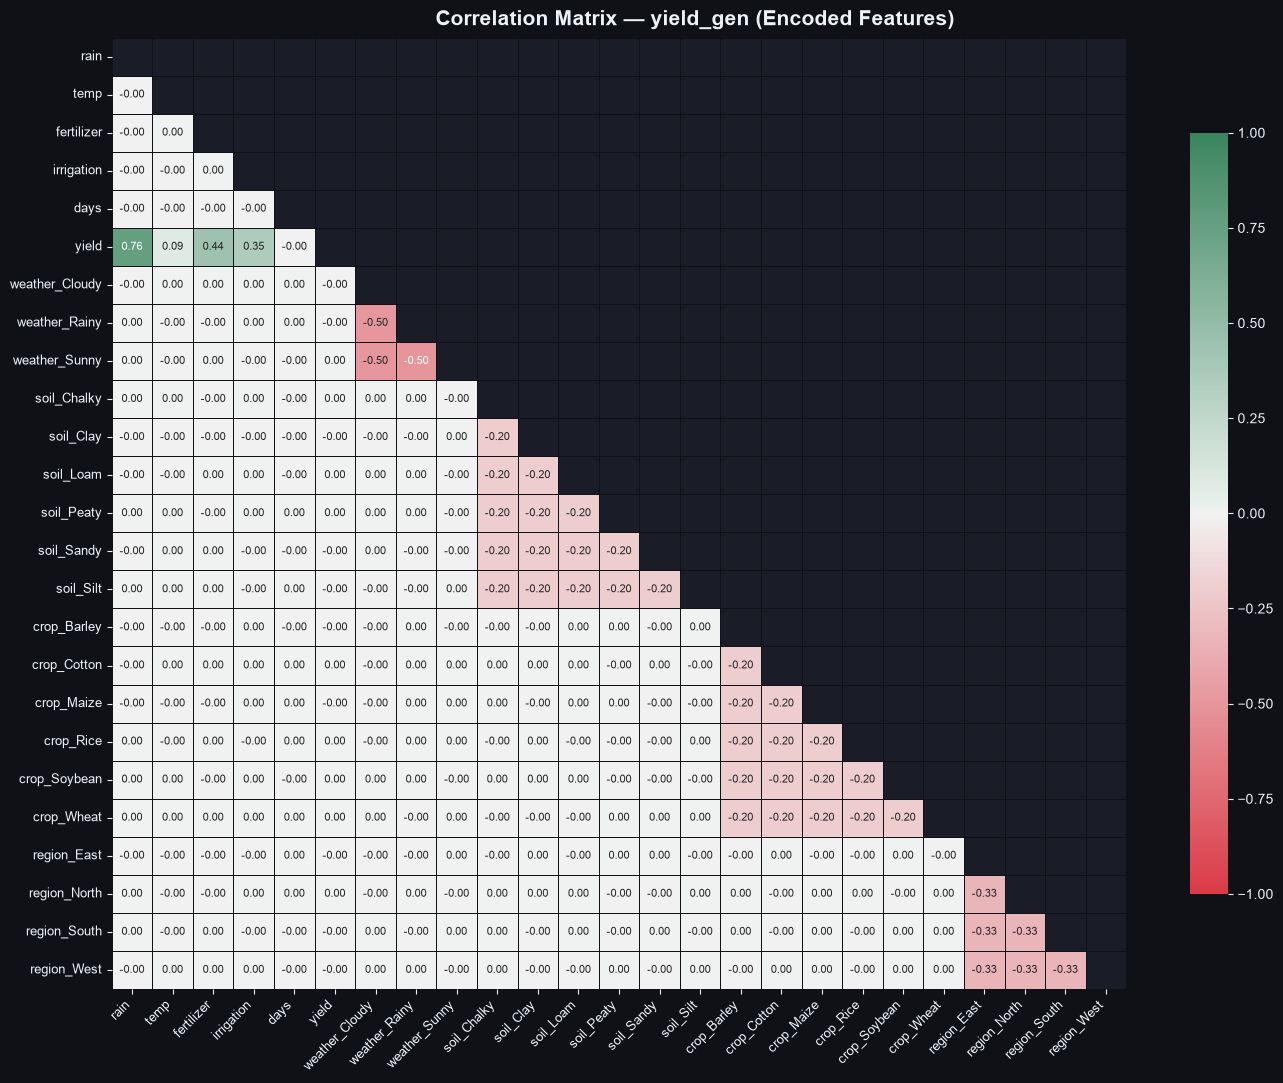

In [243]:
# 1. Préparation des données avec One-Hot Encoding
df_corr = gen.copy()

# Encodage des catégorielles et booléens.
cat_cols = ["weather", "soil", "crop", "region"]

# One-Hot Encoding sur les colonnes catégorielles.
df_encoded = pd.get_dummies(df_corr, columns=cat_cols, drop_first=False)


# 2. Calcul de la matrice de corrélation
corr = df_encoded.corr()

# Masque pour cacher la partie supérieure symétrique.
mask = np.triu(np.ones_like(corr, dtype=bool))

# 3. Visualisation de la Heatmap
fig, ax = plt.subplots(figsize=(14, 11))
fig.suptitle(
    "Correlation Matrix — yield_gen (Encoded Features)",
    fontsize=15,
    fontweight="bold",
    y=0.98,
)
fig.patch.set_facecolor(BG_COLOR)

cmap = sns.diverging_palette(10, 145, as_cmap=True)

sns.heatmap(
    corr,
    ax=ax,
    mask=mask,
    cmap=cmap,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor=BG_COLOR,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 8},
)

ax.tick_params(colors=TEXT_COLOR, labelsize=9)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(
    PLOTS / "fig_corr_heatmap_yield_gen.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR,
)
plt.show()

**Lecture de la heatmap** :
- `yield` est fortement corrélé à `rain` (0.76), plus modérément à `fertilizer` (0.44) et `irrigation` (0.35), et quasi pas à `temp` (0.09) ni `days` (~0.00).
- Toutes les variables catégorielles encodées (`weather`, `soil`, `crop`, `region`) affichent une corrélation quasi nulle (~0.00) avec `yield` — aucun effet du type de sol, de la culture, de la région ou de la météo sur le rendement.
- Les corrélations négatives entre modalités d'une même catégorie sont **exactement** -1/(k-1) selon le nombre k de modalités : -0.50 pour `weather` (k=3), -0.20 pour `soil` et `crop` (k=6), -0.33 pour `region` (k=4). C'est la signature d'un one-hot encoding sur des catégories tirées uniformément au hasard (effectifs quasi identiques, vérifié sur les `value_counts`) — pas un signal, mais une confirmation que ces variables sont générées indépendamment de `yield`.

➔ Le rendement de `gen` semble généré par une combinaison linéaire simple de `rain`, `fertilizer` et `irrigation` (+ un peu de bruit via `temp`), sans aucune dépendance aux variables catégorielles — un signal irréaliste pour un vrai jeu de données agricole. Hypothèse d'une formule synthétique à confirmer par l'ACP et le reverse-engineering ci-dessous.

### ACP (analyse en composantes principales)

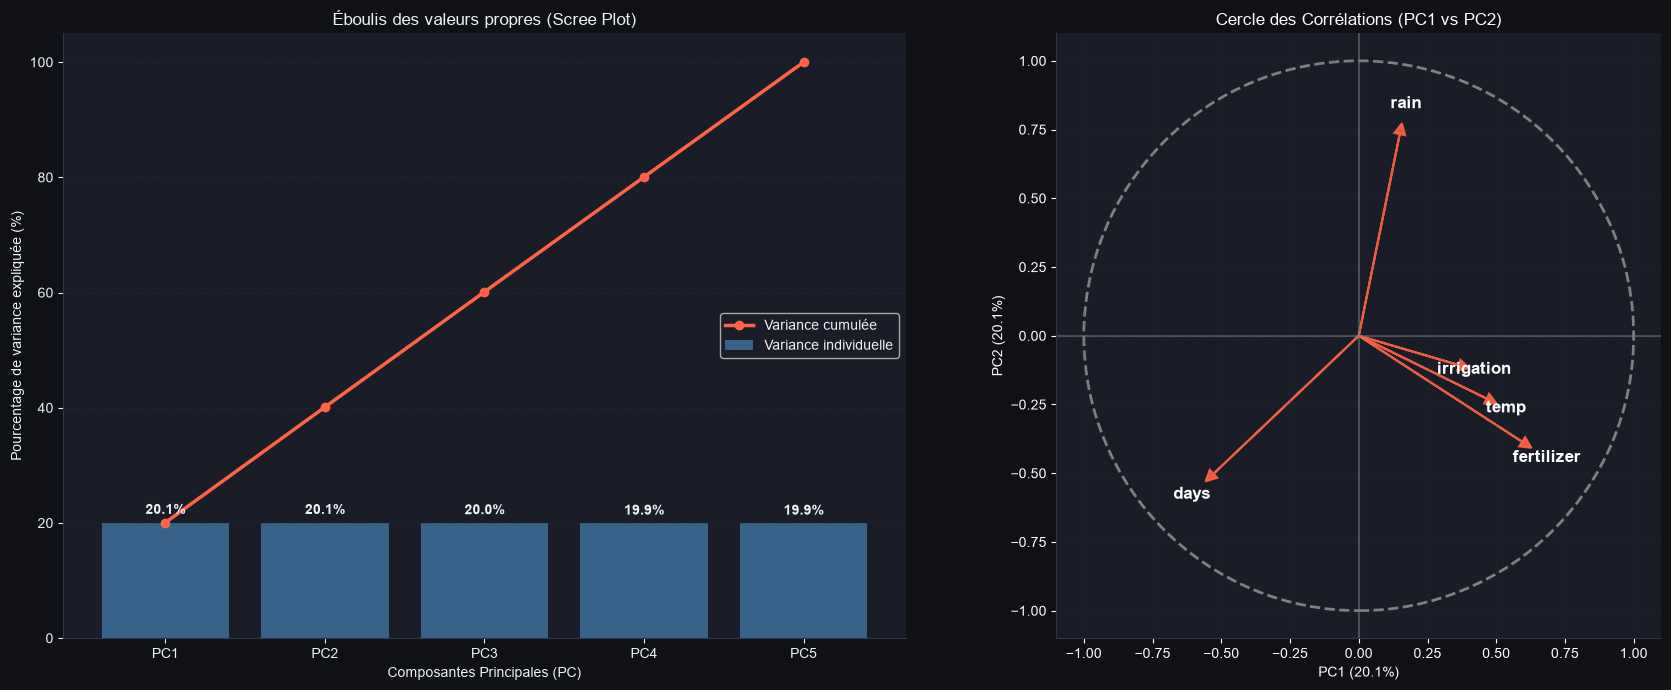

In [ ]:
# 1. Sélection des variables numériques
# (on exclut la cible 'yield' : l'ACP décrit ici la structure...
# ...des prédicteurs, pas la cible).
numerical_features = ["rain", "temp", "days", "fertilizer", "irrigation"]
X_pca = gen[numerical_features]

# 2. Standardisation des données (Crucial pour l'ACP)
scaler = preprocessing.StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

# On repasse en numpy array au cas où votre paramètre transform_output="pandas" soit encoreactif
X_scaled_arr = np.array(X_scaled)

# 3. Calcul de l'ACP
pca = decomposition.PCA()
pca.fit(X_scaled_arr)

# 4. Extraction de la variance expliquée par composante (en pourcentage)
explained_variance = pca.explained_variance_ratio_ * 100
cumulative_variance = np.cumsum(explained_variance)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# 5a. Éboulis des valeurs propres (Scree Plot)
bars = ax1.bar(
    range(1, len(explained_variance) + 1),
    explained_variance,
    alpha=0.7,
    color="steelblue",
    label="Variance individuelle",
)
ax1.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o",
    color="tomato",
    linewidth=2.5,
    label="Variance cumulée",
)
for bar in bars:
    yval = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 1,
        f"{yval:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )
ax1.set_title("Éboulis des valeurs propres (Scree Plot)")
ax1.set_xlabel("Composantes Principales (PC)")
ax1.set_ylabel("Pourcentage de variance expliquée (%)")
ax1.set_xticks(
    range(1, len(explained_variance) + 1),
    [f"PC{i}" for i in range(1, len(explained_variance) + 1)],
)
ax1.set_ylim(0, 105)
ax1.legend(loc="center right")
ax1.grid(axis="y", alpha=0.3)

# 5b. Cercle des corrélations (PC1 vs PC2)
coordonnees = pca.components_.T * np.sqrt(pca.explained_variance_)

ax2.set_xlim(-1.1, 1.1)
ax2.set_ylim(-1.1, 1.1)
ax2.set_aspect("equal")

circle = plt.Circle((0, 0), 1, color="gray", fill=False, linestyle="--", linewidth=2)
ax2.add_artist(circle)
ax2.axhline(0, color="gray", linestyle="-", alpha=0.5)
ax2.axvline(0, color="gray", linestyle="-", alpha=0.5)

for i, feature in enumerate(numerical_features):
    x = coordonnees[i, 0]
    y = coordonnees[i, 1]
    ax2.arrow(
        0,
        0,
        x,
        y,
        head_width=0.04,
        head_length=0.04,
        color="tomato",
        alpha=0.9,
        linewidth=1.5,
    )
    ax2.text(
        x * 1.15,
        y * 1.15,
        feature,
        color="white",
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
    )

ax2.set_title("Cercle des Corrélations (PC1 vs PC2)", color="white")
ax2.set_xlabel(f"PC1 ({explained_variance[0]:.1f}%)", color="white")
ax2.set_ylabel(f"PC2 ({explained_variance[1]:.1f}%)", color="white")
ax2.tick_params(colors="white")
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

**Lecture de l'ACP** :
- Le scree plot répartit la variance de façon quasi parfaitement égale entre les 5 composantes (PC1=20.07%, PC2=20.05%, PC3=20.01%, PC4=19.94%, PC5=19.93%) — aucune réduction de dimension n'est possible, chaque variable porte sa propre part de variance.
- Ça s'explique directement par la matrice de corrélation entre prédicteurs (`rain`, `temp`, `days`, `fertilizer`, `irrigation`) : tous les coefficients croisés sont ~0.000. Les 5 variables numériques sont mutuellement indépendantes.
- Le cercle des corrélations (PC1 vs PC2) n'est donc pas interprétable comme une vraie structure : avec des valeurs propres quasi identiques, l'orientation des axes PC1/PC2 est arbitraire (n'importe quelle rotation dans cet espace serait tout aussi valide).

➔ Chaque variable de `gen` est tirée indépendamment au hasard, sans aucune corrélation croisée réaliste — en agronomie réelle, température et pluviométrie sont typiquement corrélées via le climat/la région. C'est un signal supplémentaire que `gen` est un jeu de données synthétique plutôt qu'une simulation réaliste.

### Régression linéaire : la formule de génération

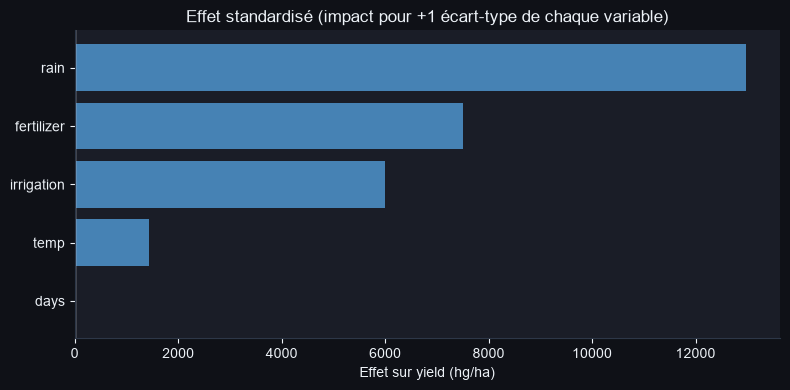

In [245]:
numerical_features = ["rain", "temp", "days", "fertilizer", "irrigation"]
X = gen[numerical_features]
y = gen["yield"]

lr_full = linear_model.LinearRegression()
lr_full.fit(X, y)

coefs_full = pd.Series(lr_full.coef_, index=numerical_features)
# Effet standardisé (impact pour +1 écart-type) : rend les coefficients comparables
# entre variables d'unités différentes (mm, °C, jours, indicatrice 0/1).
std_effect = (coefs_full * X.std()).sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 4))
colors = ["tomato" if name == "days" else "steelblue" for name in std_effect.index]
plt.barh(std_effect.index, std_effect.values, color=colors)
plt.axvline(0, color=TEXT_COLOR, linewidth=1)
plt.title("Effet standardisé (impact pour +1 écart-type de chaque variable)")
plt.xlabel("Effet sur yield (hg/ha)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**Lecture du graphe** : `days` ressort avec un effet standardisé quasi nul (+6.9 hg/ha) très loin derrière `rain` (+12 984), `fertilizer` (+7 502), `irrigation` (+5 998) et `temp` (+1 439). On écarte donc `days` et on recalcule les coefficients finaux sur les 4 variables restantes.

In [246]:
numerical_features = ["rain", "temp", "fertilizer", "irrigation"]
X = gen[numerical_features]

lr = linear_model.LinearRegression()
lr.fit(X, y)
r2 = metrics.r2_score(y, lr.predict(X))

coefs = pd.Series(lr.coef_, index=numerical_features)

print(f"yield ≈ {lr.intercept_:,.2f}")
for name, coef in coefs.items():
    print(f"        {coef:+,.4f} · {name}")
print(f"\nR² = {r2:.5f}")


yield ≈ 40.63
        +49.9668 · rain
        +199.2354 · temp
        +15,004.1447 · fertilizer
        +11,996.4216 · irrigation

R² = 0.91298


In [247]:
# 1. Échantillonnage
sample_df = gen.sample(n=6000, random_state=42).copy()

sample_df["fertilizer_str"] = sample_df["fertilizer"].map({1: "Fert=1", 0: "Fert=0"})
sample_df["irrigation_str"] = sample_df["irrigation"].map({1: "Irrig=1", 0: "Irrig=0"})
sample_df["combination"] = (
    sample_df["fertilizer_str"] + " | " + sample_df["irrigation_str"]
)

combo_colors = {
    "Fert=0 | Irrig=0": "#e74c3c",  # Rouge
    "Fert=0 | Irrig=1": "#f39c12",  # Orange
    "Fert=1 | Irrig=0": "#3498db",  # Bleu
    "Fert=1 | Irrig=1": "#2ecc71",  # Vert
}

# Coefficients réels, extraits du LinearRegression fitté plus haut (sans `days`,
# déjà écarté après lecture de l'effet standardisé).
coef_rain, coef_temp, coef_fert, coef_irrig = lr.coef_
intercept = lr.intercept_

fig = go.Figure()

# Grille pour les plans 3D
x_range = np.linspace(sample_df["rain"].min(), sample_df["rain"].max(), 15)
y_range = np.linspace(sample_df["temp"].min(), sample_df["temp"].max(), 15)
x_grid, y_grid = np.meshgrid(x_range, y_range)

combos_list = [
    (0, 0, "Fert=0 | Irrig=0"),
    (0, 1, "Fert=0 | Irrig=1"),
    (1, 0, "Fert=1 | Irrig=0"),
    (1, 1, "Fert=1 | Irrig=1"),
]

for fert_val, irrig_val, label in combos_list:
    subset = sample_df[sample_df["combination"] == label]
    color = combo_colors[label]

    # 1. Nuage de points réels (3D)
    fig.add_trace(
        go.Scatter3d(
            x=subset["rain"],
            y=subset["temp"],
            z=subset["yield"],
            mode="markers",
            name=label,
            marker={"size": 3, "color": color, "opacity": 0.6},
        )
    )

    # 2. Plan 3D de régression pour cette combinaison
    z_grid = (
        intercept
        + coef_rain * x_grid
        + coef_temp * y_grid
        + coef_fert * fert_val
        + coef_irrig * irrig_val
    )
    fig.add_trace(
        go.Surface(
            x=x_grid,
            y=y_grid,
            z=z_grid,
            showscale=False,
            opacity=0.3,
            colorscale=[[0, color], [1, color]],
            name=f"Plan {label}",
            hoverinfo="skip",
        )
    )

# Mise en page Plotly corrigée (compatible toutes versions)
fig.update_layout(
    title={
        "text": "Plotly 3D Interactif : Yield = f(Rain, Temp) par (Fertilizer, Irrigation)",
        "font": {"size": 15, "color": "#edf2f7"},
    },
    paper_bgcolor="#0f1117",
    plot_bgcolor="#1a1d27",
    scene={
        "xaxis": {
            "title": "Rainfall (mm)",
            "color": "#edf2f7",
            "backgroundcolor": "#1a1d27",
            "gridcolor": "#2d3748",
        },
        "yaxis": {
            "title": "Temperature (°C)",
            "color": "#edf2f7",
            "backgroundcolor": "#1a1d27",
            "gridcolor": "#2d3748",
        },
        "zaxis": {
            "title": "Yield (hg/ha)",
            "color": "#edf2f7",
            "backgroundcolor": "#1a1d27",
            "gridcolor": "#2d3748",
        },
    },
    legend={"font": {"color": "#edf2f7"}},
    margin={"l": 0, "r": 0, "b": 0, "t": 40},
)

fig.show()


**Formule recomposée (hors `days`)** : yield ≈ 40.63 + 49.97·rain + 199.24·temp + 15 004.14·fertilizer + 11 996.42·irrigation, R² = 0.91298.

- En coefficients bruts, `fertilizer` et `irrigation` dominent visuellement (+15 004 et +11 996) simplement parce que ce sont des indicatrices 0/1 à faible variance — pas comparables aux variables continues. En **effet standardisé** (impact pour +1 écart-type, calculé ci-dessus avant d'écarter `days`), le vrai classement est : `rain` (+12 984) > `fertilizer` (+7 502) > `irrigation` (+5 998) > `temp` (+1 439) >> `days` (+6.9, négligeable) — cohérent avec les corrélations de la heatmap (`rain` 0.76 >> `fertilizer` 0.44 > `irrigation` 0.35 > `temp` 0.09 > `days` ~0.00).
- Retirer `days` ne change quasiment rien au R² (0.91298 avec ou sans) : il ne portait aucun signal, seulement du bruit statistique.
- Un R² de 0.913 avec une simple régression linéaire à 4 variables est déjà quasi identique à ce qu'un modèle non linéaire (Random Forest) obtiendrait sur les mêmes variables — le signal est purement linéaire. Une seule régression suffit donc à confirmer que `gen` est une formule synthétique + bruit, sans besoin d'aller plus loin (feature importance, analyse de résidus, PDP).

### Conclusion : dataset `gen` écarté

- L'ACP montre l'inverse d'une structure partagée : variance répartie quasi également entre les 5 composantes (~20% chacune) car les prédicteurs sont mutuellement indépendants (corrélations croisées ~0.000) — chaque variable de `gen` est tirée au hasard indépendamment des autres, contrairement à des variables agronomiques réelles qui présenteraient des corrélations croisées (climat, région, etc.).
- L'effet standardisé isole `days` comme seule variable au poids négligeable (+6.9 hg/ha) ; une fois `days` écarté, la régression linéaire sur les 4 variables restantes recompose la formule de génération quasiment telle quelle (R²=0.91298), confirmant les ~0.00 de corrélation vus sur la heatmap.

→ `gen` est un jeu de données **synthétique, généré par une formule linéaire simple + bruit**, pas une simulation réaliste de rendements agricoles. On l'écarte et on travaille sur le dataset **FAO** (`agri`) pour la suite du notebook.

## FAO DATASET

### Skewed target Distribution

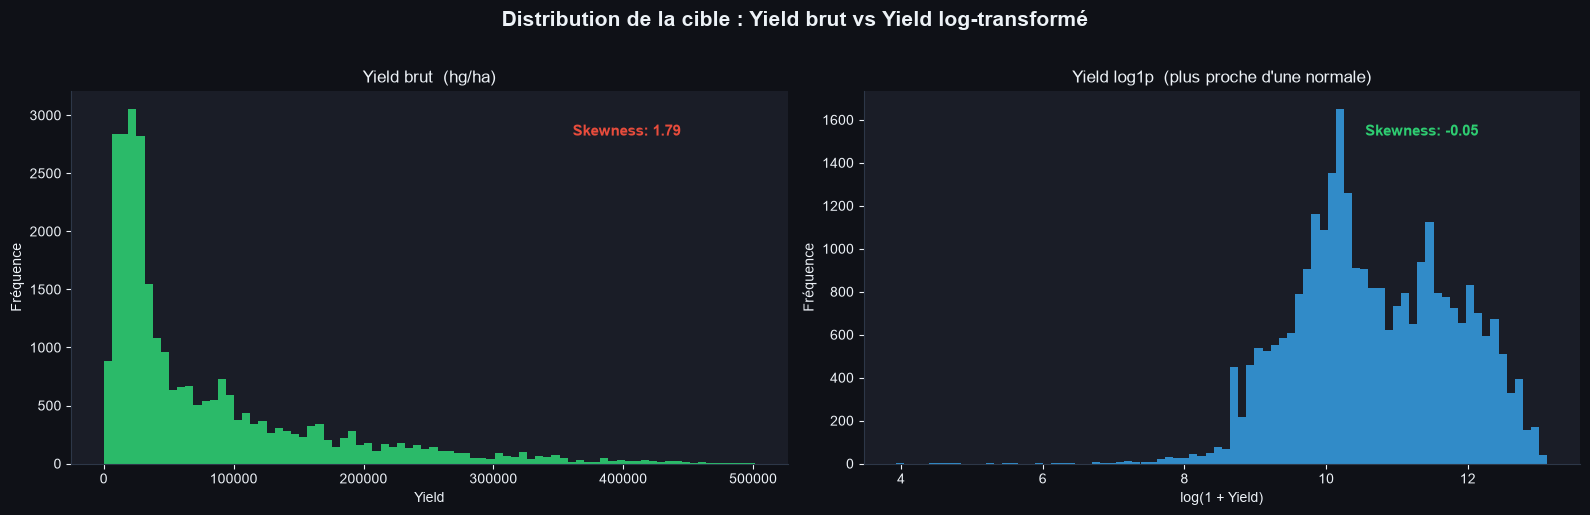

Skewness brute : 1.79
Skewness log1p : -0.05


In [248]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(
    "Distribution de la cible : Yield brut vs Yield log-transformé",
    fontsize=15,
    fontweight="bold",
    y=1.02,
)

# Distribution brute
axes[0].hist(agri["yield"], bins=80, color=ACCENT, edgecolor="none", alpha=0.9)
axes[0].set_title("Yield brut  (hg/ha)", fontsize=12)
axes[0].set_xlabel("Yield")
axes[0].set_ylabel("Fréquence")
skew_raw = agri["yield"].skew()
axes[0].text(
    0.7,
    0.88,
    f"Skewness: {skew_raw:.2f}",
    transform=axes[0].transAxes,
    color="#e74c3c",
    fontsize=11,
    fontweight="bold",
)

# Distribution log-transformée
log_yield = np.log1p(agri["yield"])  # transformation log.
axes[1].hist(log_yield, bins=80, color="#3498db", edgecolor="none", alpha=0.9)
axes[1].set_title("Yield log1p  (plus proche d'une normale)", fontsize=12)
axes[1].set_xlabel("log(1 + Yield)")
axes[1].set_ylabel("Fréquence")
skew_log = log_yield.skew()
axes[1].text(
    0.7,
    0.88,
    f"Skewness: {skew_log:.2f}",
    transform=axes[1].transAxes,
    color=ACCENT,
    fontsize=11,
    fontweight="bold",
)

plt.tight_layout()
plt.savefig(
    PLOTS / "fig_target_dist.png", dpi=150, bbox_inches="tight", facecolor=BG_COLOR
)
plt.show()

print(f"Skewness brute : {skew_raw:.2f}")
print(f"Skewness log1p : {skew_log:.2f}")


**Lecture** : le `yield` brut est fortement asymétrique à droite (skewness ≈ 1.79) — une minorité de rendements très élevés (pommes de terre, manioc) étire la distribution vers la droite. Après `log1p`, l'asymétrie tombe à ≈ -0.05, quasi nulle : la transformation log est donc pertinente pour les modèles linéaires (Ridge/LinearRegression), moins nécessaire pour les modèles à base d'arbres (RF/XGBoost), naturellement peu sensibles à ce type d'asymétrie.

### Yield distribution by Crop

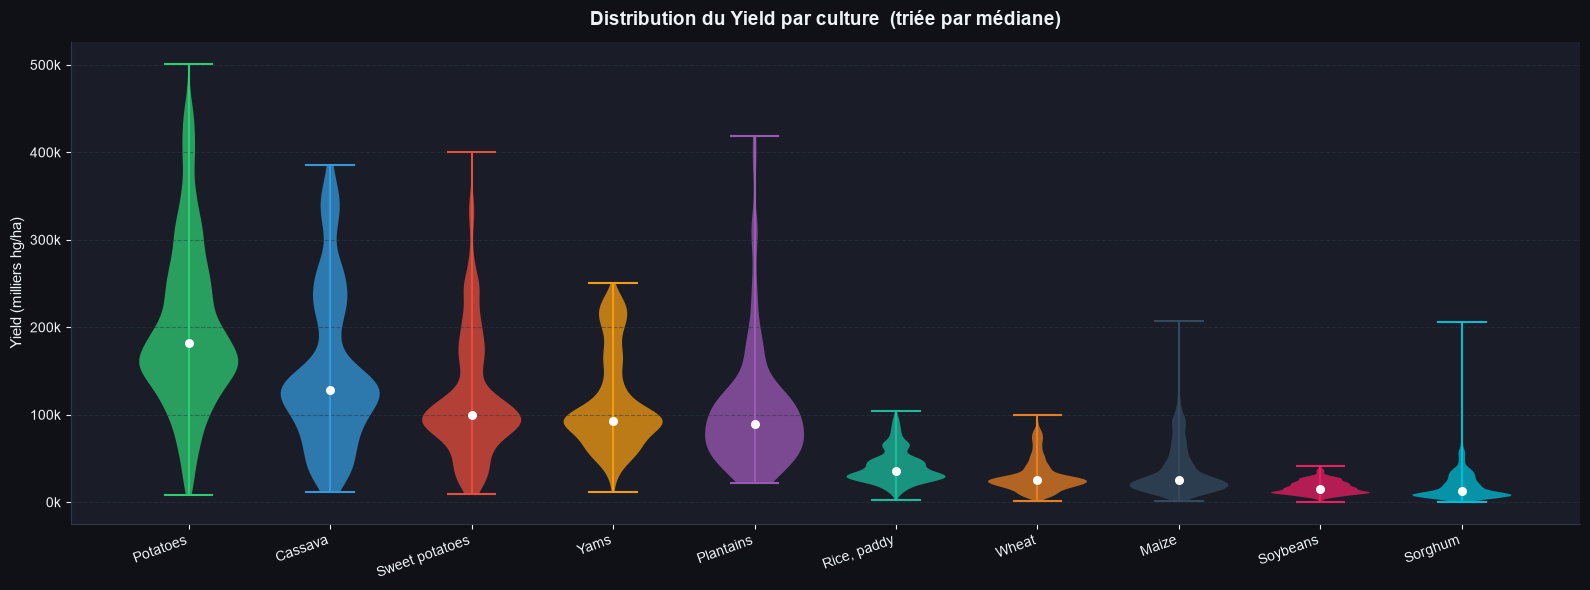

                        median       std       mean    cv
crop                                                     
Sorghum                12885.0  15118.00   18635.78  0.81
Maize                  25401.0  27456.37   36310.07  0.76
Plantains and others   89860.5  72127.98  106041.32  0.68
Wheat                  25497.0  18387.88   30116.27  0.61
Cassava               128200.0  89738.52  150479.47  0.60
Sweet potatoes         99940.0  69847.57  119057.79  0.59
Yams                   92593.0  54211.78  114140.35  0.47
Rice, paddy            35878.0  19169.70   40730.43  0.47
Potatoes              182271.0  93382.18  199801.55  0.47
Soybeans               15533.0   7603.21   16731.09  0.45


In [249]:
crop_order = (
    agri.groupby("crop")["yield"].agg("median").sort_values(ascending=False).index
)
crop_colors = {crop: PALETTE[i] for i, crop in enumerate(crop_order)}

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor(BG_COLOR)

for i, crop in enumerate(crop_order):
    data = agri[agri["crop"] == crop]["yield"] / 1000  # conversion en milliers.
    parts = ax.violinplot(data, positions=[i], widths=0.7, showmedians=False)
    for pc in parts["bodies"]:  # ty: ignore[not-iterable]
        pc.set_facecolor(crop_colors[crop])
        pc.set_alpha(0.75)
    parts["cbars"].set_color(crop_colors[crop])
    parts["cmins"].set_color(crop_colors[crop])
    parts["cmaxes"].set_color(crop_colors[crop])
    # Point blanc sur la médiane.
    ax.scatter([i], [data.median()], color="white", s=30, zorder=5)

ax.set_xticks(range(len(crop_order)))
ax.set_xticklabels(
    [c.replace(" and others", "") for c in crop_order],
    rotation=20,
    ha="right",
    fontsize=10,
)
ax.set_ylabel("Yield (milliers hg/ha)", fontsize=11)
ax.set_title(
    "Distribution du Yield par culture  (triée par médiane)",
    fontsize=14,
    fontweight="bold",
    pad=12,
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}k"))
ax.grid(axis="y")

plt.tight_layout()
plt.savefig(
    PLOTS / "fig_crop_violin.png", dpi=150, bbox_inches="tight", facecolor=BG_COLOR
)
plt.show()

# Coefficient de variation (std / mean) : dispersion relative, comparable entre cultures
# malgré leurs échelles de yield très différentes.
crop_stats = agri.groupby("crop")["yield"].agg(median="median", std="std", mean="mean")
crop_stats["cv"] = crop_stats["std"] / crop_stats["mean"]
print(crop_stats.sort_values("cv", ascending=False).round(2))


**Lecture** : `Potatoes` a la médiane la plus haute (182 271 hg/ha) et l'écart-type absolu le plus élevé (93 382), mais son coefficient de variation (0.47) est en fait le plus bas de toutes les cultures : sa dispersion est proportionnellement faible. À l'opposé, `Sorghum` a la médiane la plus basse (12 885) et le CV le plus élevé (0.81) — c'est la culture la moins stable, pas la plus prévisible comme on pourrait le lire sur le graphe. `Soybeans` combine médiane basse et CV le plus faible (0.45) : c'est elle la culture la plus stable/prévisible.

### Optimal Temperature by Crop

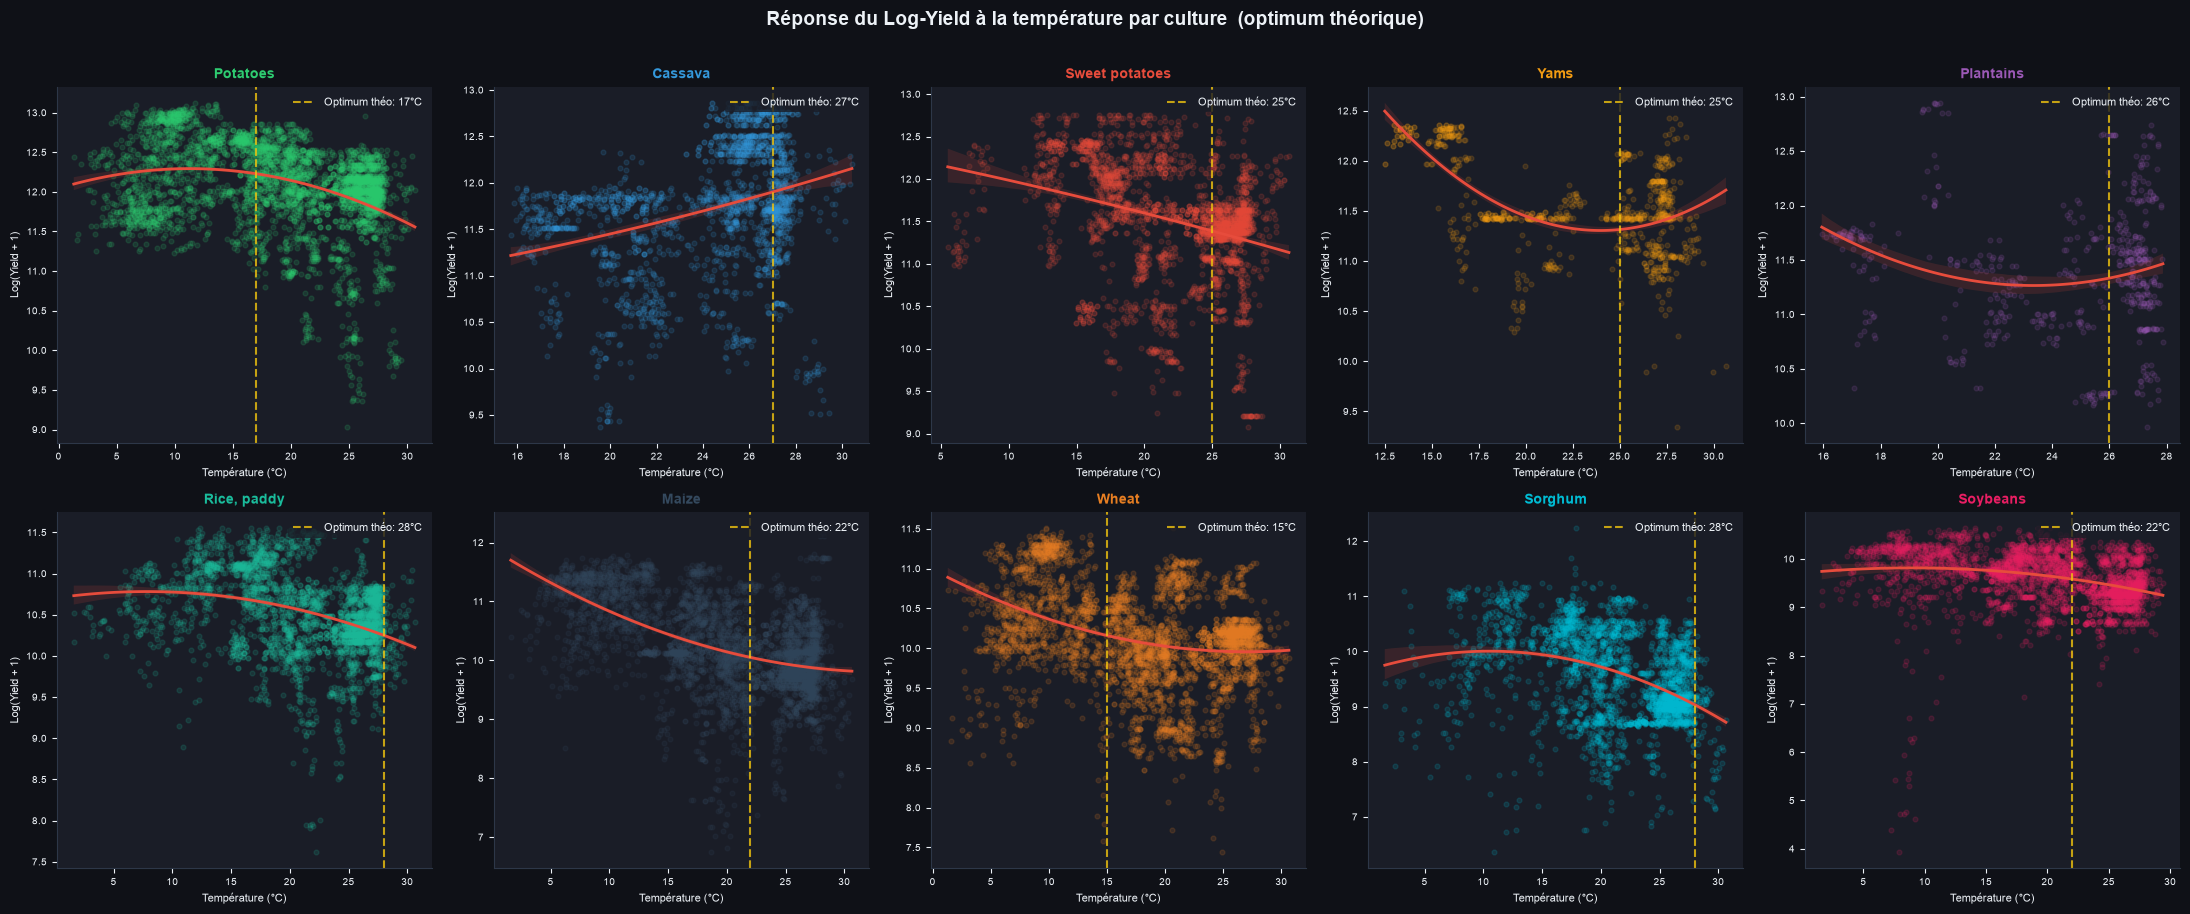

Maize                  -0.51
Yams                   -0.46
Sorghum                -0.37
Rice, paddy            -0.34
Wheat                  -0.32
Sweet potatoes         -0.31
Potatoes               -0.31
Soybeans               -0.28
Plantains and others   -0.09
Cassava                 0.32
Name: corr_temp_log_yield, dtype: float64


In [250]:
# Températures optimales théoriques par culture (°C)
CROP_OPT_TEMPS = {
    "Wheat": 15,
    "Rice, paddy": 28,
    "Maize": 22,
    "Potatoes": 17,
    "Soybeans": 22,
    "Sorghum": 28,
    "Cassava": 27,
    "Sweet potatoes": 25,
    "Plantains and others": 26,
    "Yams": 25,
}

# Yield log-transformé pour la visualisation
df_temp = agri.copy()
df_temp["log_yield"] = np.log1p(df_temp["yield"])

crop_order = df_temp.groupby("crop")["yield"].mean().sort_values(ascending=False).index

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()
fig.suptitle(
    "Réponse du Log-Yield à la température par culture  (optimum théorique)",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)
fig.patch.set_facecolor(BG_COLOR)

temp_corr = {}
for idx, crop in enumerate(crop_order):
    sub = df_temp[df_temp["crop"] == crop]
    ax = axes[idx]
    temp_corr[crop] = sub["temp"].corr(sub["log_yield"])

    # Nuage de points & régression polynomiale (degré 2) sur log_yield
    sns.regplot(
        data=sub,
        x="temp",
        y="log_yield",
        order=2,
        ax=ax,
        scatter_kws={"alpha": 0.15, "s": 12, "color": crop_colors[crop]},
        line_kws={"color": "#e74c3c", "linewidth": 2},
    )

    # Ligne de température optimale théorique
    opt_temp = CROP_OPT_TEMPS.get(crop, 22)
    ax.axvline(
        x=opt_temp,
        color="#f1c40f",
        linestyle="--",
        alpha=0.8,
        label=f"Optimum théo: {opt_temp}°C",
    )
    ax.legend(loc="upper right", fontsize=8, facecolor=CARD_COLOR, edgecolor="none")

    ax.set_title(
        crop.replace(" and others", ""),
        fontsize=10,
        color=crop_colors[crop],
        fontweight="bold",
    )
    ax.set_xlabel("Température (°C)", fontsize=8)
    ax.set_ylabel("Log(Yield + 1)", fontsize=8)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(
    PLOTS / "fig_optimal_temp_per_crop_log.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR,
)
plt.show()

print(pd.Series(temp_corr, name="corr_temp_log_yield").sort_values().round(2))


**Lecture** : la corrélation température / log-yield est négative pour 9 cultures sur 10, de faible (`Plantains and others`, -0.09) à forte (`Maize`, -0.51) — le manioc (`Cassava`) est la seule exception, avec une corrélation positive (+0.32). Le fit quadratique univarié sur `temp` seul reste peu fiable comme estimateur de l'optimum réel : plusieurs optima empiriques sortent de la plage observée ou sont incohérents avec l'optimum théorique, signe que d'autres facteurs (pays, sol, irrigation) confondent la relation température/yield.

### Temporal Trends

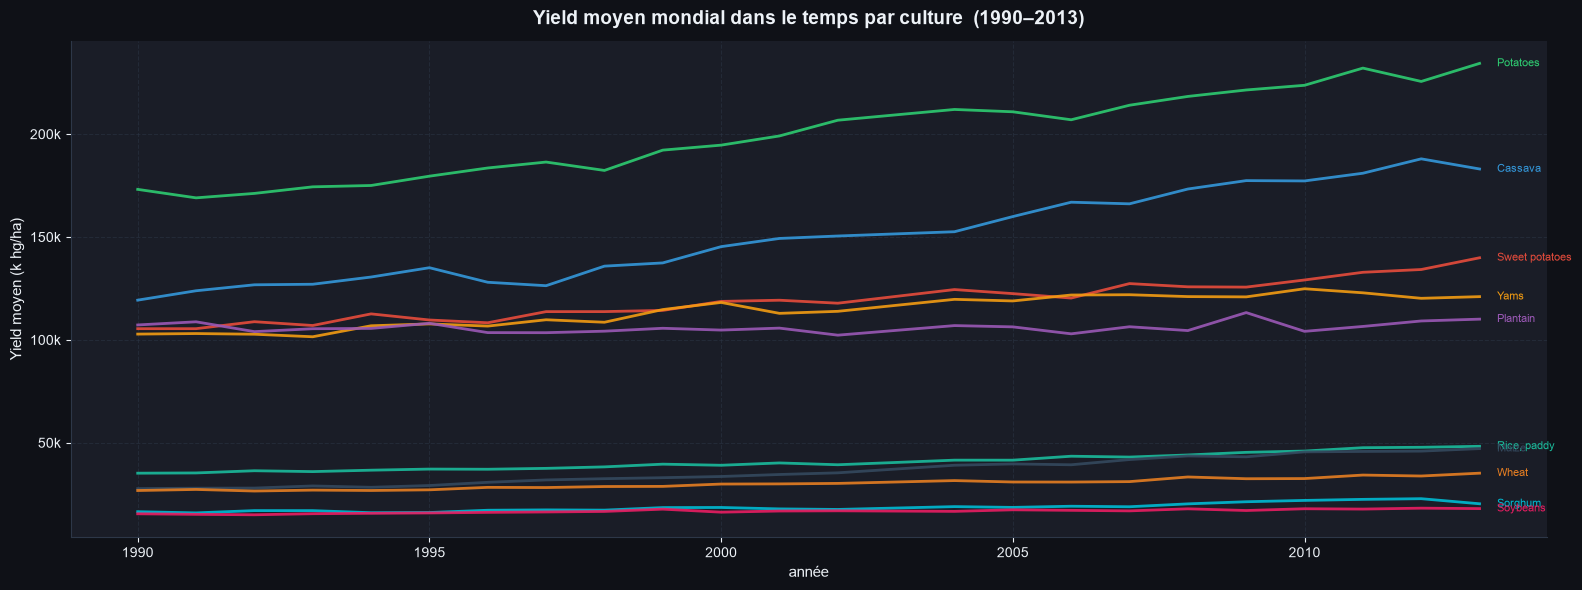

Taux de croissance du yield (1990 → 2013) :
   Potatoes                  +  35.4%  ███
   Cassava                   +  53.4%  █████
   Sweet potatoes            +  32.7%  ███
   Yams                      +  17.7%  █
   Plantains and others      +   2.6%  
   Rice, paddy               +  37.1%  ███
   Maize                     +  70.2%  ███████
   Wheat                     +  31.5%  ███
   Sorghum                   +  23.4%  ██
   Soybeans                  +  16.3%  █


In [251]:
yearly = agri.groupby(["year", "crop"])["yield"].mean().reset_index()

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor(BG_COLOR)

for i, crop in enumerate(crop_order):
    sub = yearly[yearly["crop"] == crop]
    ax.plot(
        sub["year"],
        sub["yield"] / 1000,
        color=crop_colors[crop],
        linewidth=2,
        label=crop.replace(" and others", ""),
        alpha=0.9,
    )
    # Étiquette en bout de courbe
    last = sub.iloc[-1]
    ax.text(
        last["year"] + 0.3,
        last["yield"] / 1000,
        crop.replace(" and others", "").replace("Plantains", "Plantain"),
        color=crop_colors[crop],
        fontsize=8,
        va="center",
    )

ax.set_xlabel("année", fontsize=11)
ax.set_ylabel("Yield moyen (k hg/ha)", fontsize=11)
ax.set_title(
    "Yield moyen mondial dans le temps par culture  (1990–2013)",
    fontsize=14,
    fontweight="bold",
    pad=12,
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}k"))
ax.grid(True)

plt.tight_layout()
plt.savefig(
    PLOTS / "fig_yield_trend.png", dpi=150, bbox_inches="tight", facecolor=BG_COLOR
)
plt.show()

# Calcul des taux de croissance
print("Taux de croissance du yield (1990 → 2013) :")
for crop in crop_order:
    sub = yearly[yearly["crop"] == crop].set_index("year")
    start = sub["yield"].iloc[0]
    end = sub["yield"].iloc[-1]
    pct = ((end - start) / start) * 100
    bar = "█" * int(abs(pct) // 10)
    sign = "+" if pct > 0 else ""
    print(f"   {crop:<25} {sign}{pct:6.1f}%  {bar}")


**Lecture** : toutes les cultures progressent entre 1990 et 2013, aucune n'est en déclin. `Maize` progresse le plus (+70%), suivi de `Cassava` (+53%) ; à l'opposé, `Plantains and others` stagne presque (+2.6%), et `Soybeans`/`Yams` progressent aussi peu (+16%/+18%). Cette hausse générale reflète probablement des progrès agronomiques (intrants, sélection variétale, irrigation) plutôt qu'un effet climatique isolé.

### Correlation Heatmap

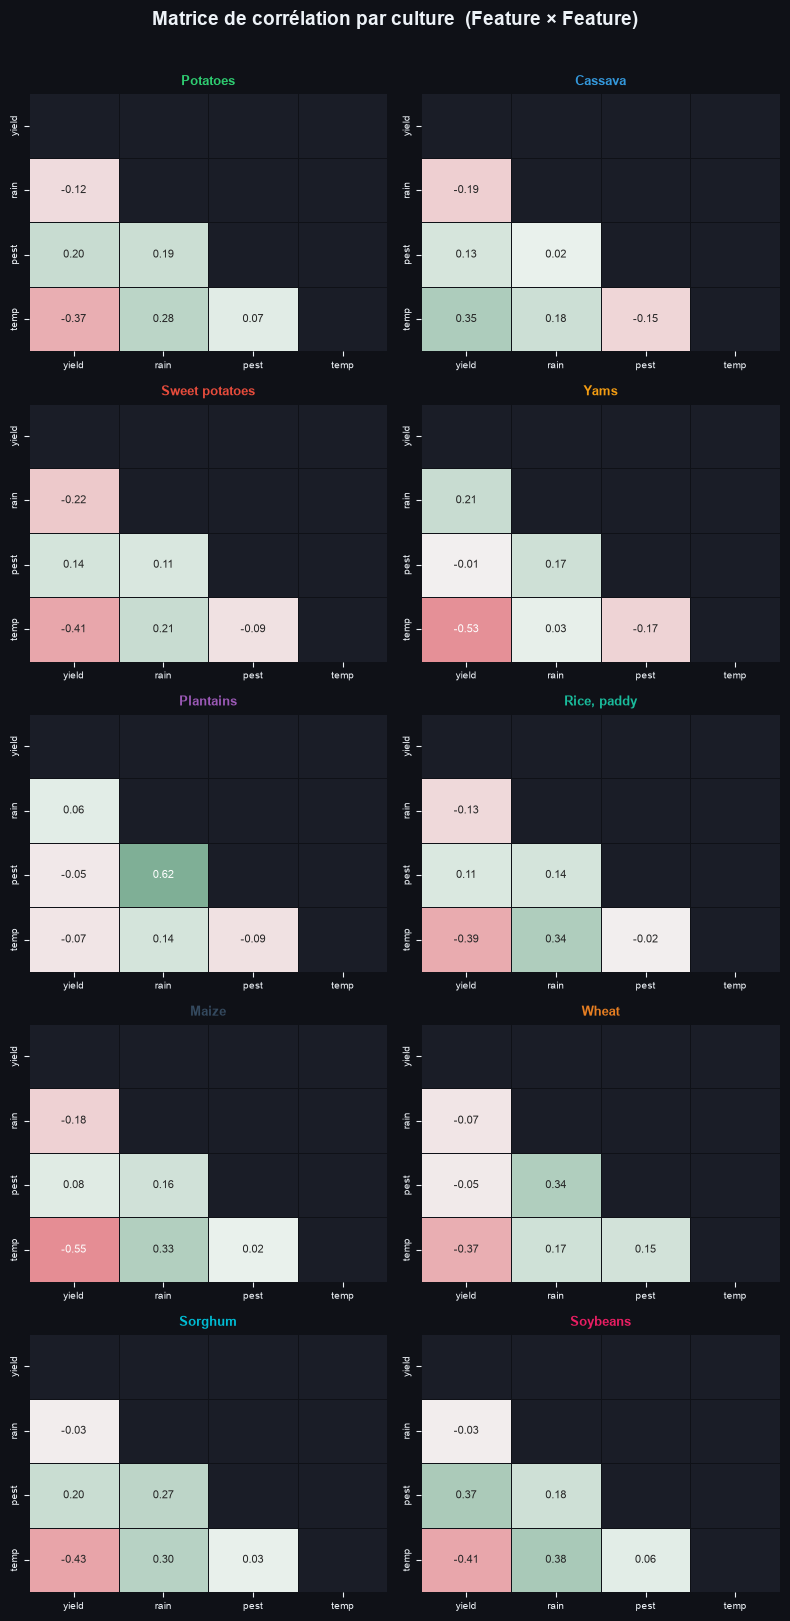

                      rain  pest  temp
Potatoes             -0.12  0.20 -0.37
Cassava              -0.19  0.13  0.35
Sweet potatoes       -0.22  0.14 -0.41
Yams                  0.21 -0.01 -0.53
Plantains and others  0.06 -0.05 -0.07
Rice, paddy          -0.13  0.11 -0.39
Maize                -0.18  0.08 -0.55
Wheat                -0.07 -0.05 -0.37
Sorghum              -0.03  0.20 -0.43
Soybeans             -0.03  0.37 -0.41


In [252]:
features = [
    "yield",
    "rain",
    "pest",
    "temp",
]

fig, axes = plt.subplots(5, 2, figsize=(8, 16))
axes = axes.flatten()
fig.suptitle(
    "Matrice de corrélation par culture  (Feature × Feature)",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)
fig.patch.set_facecolor(BG_COLOR)

corr_yield = {}
for idx, crop in enumerate(crop_order):
    sub = agri[agri["crop"] == crop][features]
    corr = sub.corr()
    corr_yield[crop] = corr.loc["yield", ["rain", "pest", "temp"]]
    mask = np.triu(np.ones_like(corr, dtype=bool))

    cmap = sns.diverging_palette(10, 145, as_cmap=True)
    sns.heatmap(
        corr,
        ax=axes[idx],
        mask=mask,
        cmap=cmap,
        vmin=-1,
        vmax=1,
        annot=True,
        fmt=".2f",
        linewidths=0.5,
        linecolor="#0f1117",
        cbar=False,
        annot_kws={"size": 8},
    )
    axes[idx].set_title(
        crop.replace(" and others", ""),
        fontsize=9,
        color=crop_colors[crop],
        fontweight="bold",
    )
    axes[idx].tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(
    PLOTS / "fig_corr_per_crop.png", dpi=150, bbox_inches="tight", facecolor=BG_COLOR
)
plt.show()

print(pd.DataFrame(corr_yield).T.round(2))


**Lecture** : `temp` est corrélée positivement au yield uniquement pour `Cassava` (+0.35) ; pour les 9 autres cultures elle est négative, de -0.07 (`Plantains and others`) à -0.55 (`Maize`) — un modèle climatique unique pour toutes les cultures serait donc mal spécifié. `rain` a un effet faible et de signe instable selon la culture (-0.22 à +0.21). `pest` est plutôt corrélée positivement (jusqu'à +0.37 pour `Soybeans`), sauf pour `Yams`, `Wheat` et `Plantains and others` (léger négatif).

### Pesticide regressions

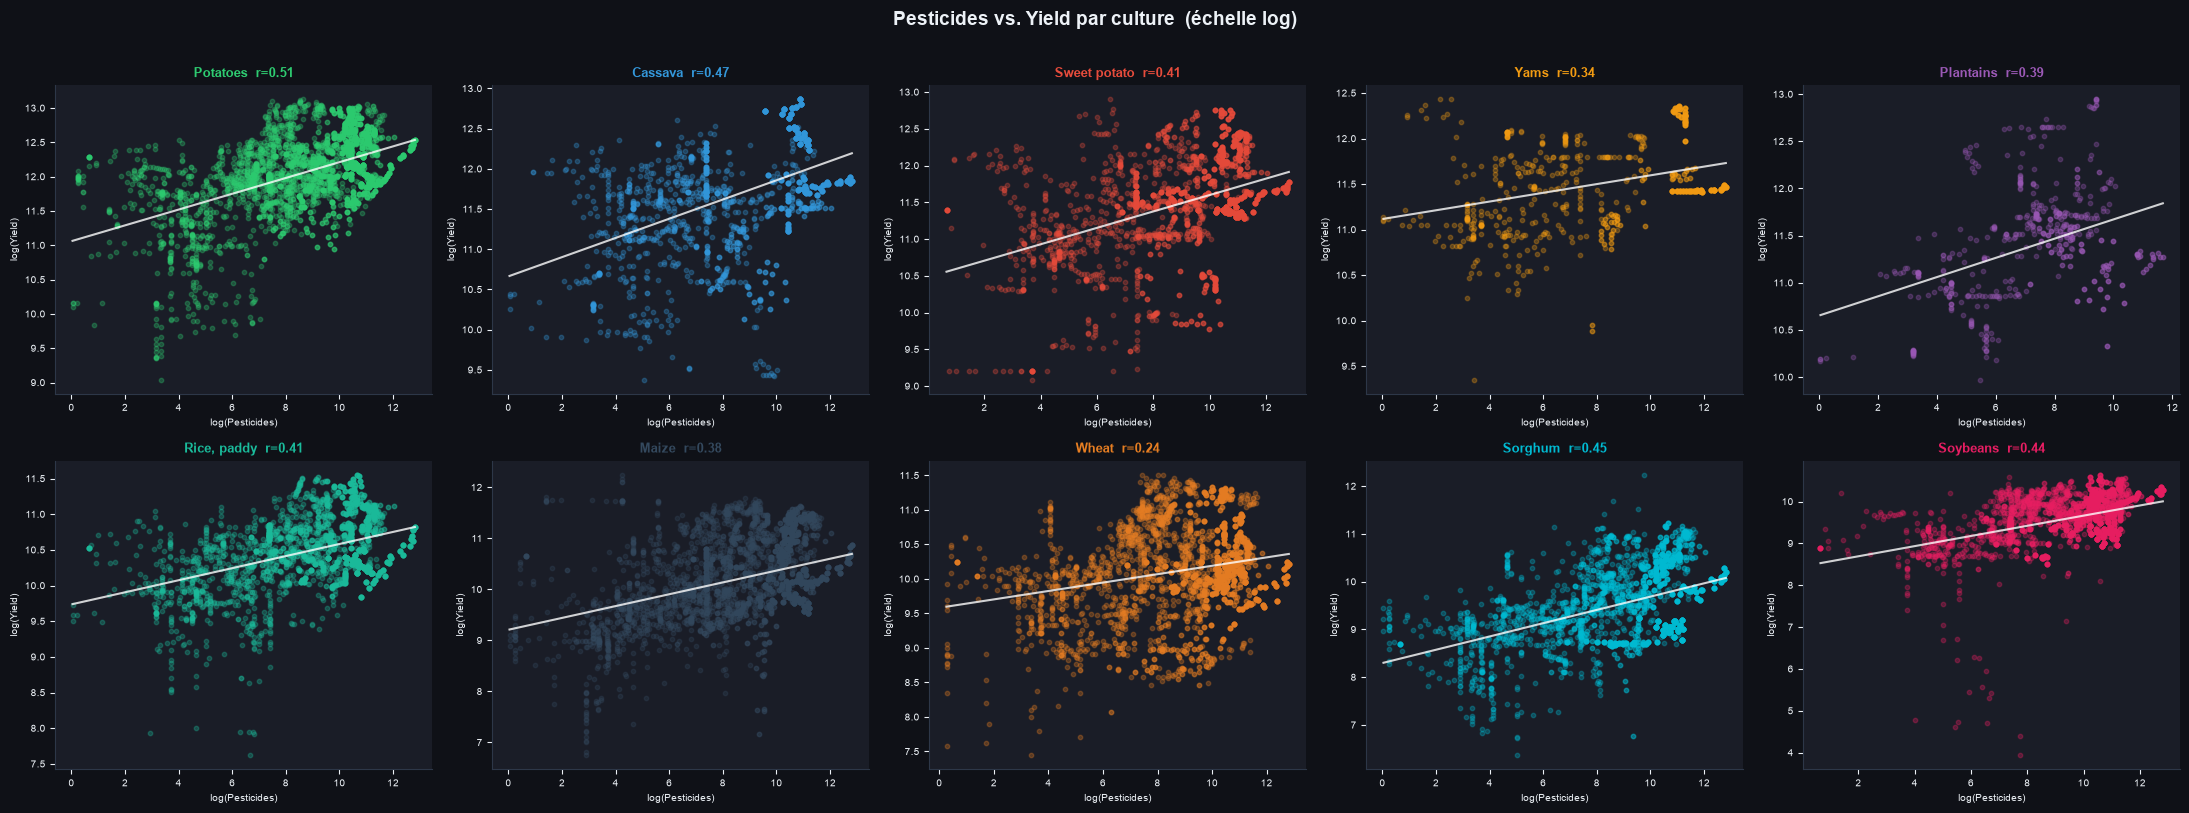

Wheat                   0.24
Yams                    0.34
Maize                   0.38
Plantains and others    0.39
Sweet potatoes          0.41
Rice, paddy             0.41
Soybeans                0.44
Sorghum                 0.45
Cassava                 0.47
Potatoes                0.51
dtype: float64

Plage de r : [0.24, 0.51]


In [253]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()
fig.suptitle(
    "Pesticides vs. Yield par culture  (échelle log)",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)
fig.patch.set_facecolor(BG_COLOR)

pest_corr = {}
for idx, crop in enumerate(crop_order):
    sub = agri[agri["crop"] == crop].copy()
    sub = sub[sub["pest"] > 0]
    color = crop_colors[crop]

    axes[idx].scatter(
        np.log1p(sub["pest"]),
        np.log1p(sub["yield"]),
        alpha=0.3,
        s=10,
        color=color,
    )

    # Droite de tendance
    x = np.log1p(sub["pest"])
    y = np.log1p(sub["yield"])
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    x_line = np.linspace(x.min(), x.max(), 100)
    axes[idx].plot(x_line, p(x_line), color="white", linewidth=1.5, alpha=0.8)

    r = np.corrcoef(x, y)[0, 1]
    pest_corr[crop] = r
    axes[idx].set_title(
        f"{crop.replace(' and others', '')[:12]}  r={r:.2f}",
        fontsize=9,
        color=color,
        fontweight="bold",
    )
    axes[idx].set_xlabel("log(Pesticides)", fontsize=7)
    axes[idx].set_ylabel("log(Yield)", fontsize=7)
    axes[idx].tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(
    PLOTS / "fig_pesticide_scatter.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR,
)
plt.show()

pest_corr = pd.Series(pest_corr).sort_values()
print(pest_corr.round(2))
print(f"\nPlage de r : [{pest_corr.min():.2f}, {pest_corr.max():.2f}]")


**Lecture** : après log-transformation, la corrélation pesticides/yield reste positive pour les 10 cultures, entre +0.24 (`Wheat`) et +0.51 (`Potatoes`) — un signal modéré et stable, pas une relation qui « varie sauvagement » comme un simple coup d'œil au graphe pourrait le suggérer. Cette corrélation est probablement confondue par la richesse du pays (plus de moyens ⇒ plus de pesticides ET de meilleurs rendements), une variable absente du dataset.

### Geographical presence

In [254]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Ordre et couleurs uniques par culture (cohérents avec la PALETTE de votre notebook)
crop_order = sorted(agri["crop"].unique())
crop_colors = {crop: PALETTE[i % len(PALETTE)] for i, crop in enumerate(crop_order)}

# 2. Création d'une grille 2x5 de cartes géo
fig = make_subplots(
    rows=2,
    cols=5,
    subplot_titles=[c.replace(" and others", "")[:15] for c in crop_order],
    specs=[[{"type": "geo"}] * 5] * 2,
    horizontal_spacing=0.01,
    vertical_spacing=0.08,
)

# 3. Traitement de chaque culture
for idx, crop in enumerate(crop_order):
    row = (idx // 5) + 1
    col = (idx % 5) + 1
    color = crop_colors[crop]

    # Pays producteurs de la culture
    sub_df = agri[agri["crop"] == crop]["country"].unique()
    producer_df = pd.DataFrame({"country": sub_df, "Produces": 1})

    # Trace Choropleth avec couleur fixe de la culture
    fig.add_trace(
        go.Choropleth(
            locations=producer_df["country"],
            locationmode="country names",
            z=producer_df["Produces"],
            colorscale=[[0, color], [1, color]],
            showscale=False,
            name=crop,
            hovertemplate=f"<b>%{{location}}</b><br>Produces: {crop}<extra></extra>",
        ),
        row=row,
        col=col,
    )

    # Configuration du style sombre pour la mini-carte
    geo_key = f"geo{idx + 1}" if idx > 0 else "geo"
    fig.layout[geo_key].update(
        bgcolor="#0f1117",
        showframe=False,
        showcoastlines=True,
        coastlinecolor="#2d3748",
        showland=True,
        landcolor="#1a1d27",  # Pays non-producteurs non coloriés (fond sombre)
        showocean=True,
        oceancolor="#0f1117",
        projection_scale=0.85,
    )

# 4. Thème global et titre
fig.update_layout(
    title={
        "text": "<b>🌍 Pays producteurs par culture (carte de présence)</b>",
        "font": {"size": 16, "color": "#edf2f7"},
        "x": 0.5,
    },
    paper_bgcolor="#0f1117",
    font={"color": "#edf2f7", "size": 10},
    height=550,
    margin={"l": 10, "r": 10, "t": 60, "b": 10},
)

# Style des sous-titres de culture (avec la couleur de la culture)
for i, annotation in enumerate(fig.layout.annotations):
    crop_name = crop_order[i]
    annotation.font.color = crop_colors[crop_name]
    annotation.font.size = 11
    annotation.font.weight = "bold"

fig.show()

# 5. Étendue géographique : nombre de pays producteurs et dispersion climatique
geo_spread = agri.groupby("crop").apply(
    lambda g: pd.Series(
        {
            "n_countries": g["country"].nunique(),
            "mean_temp": g["temp"].mean(),
            "temp_std_across_countries": g.groupby("country")["temp"].mean().std(),
        }
    ),
    include_groups=False,
)
print(geo_spread.sort_values("n_countries").round(2))


                      n_countries  mean_temp  temp_std_across_countries
crop                                                                   
Plantains and others         21.0      24.24                       3.41
Yams                         21.0      22.70                       4.25
Cassava                      41.0      24.21                       3.41
Sweet potatoes               53.0      22.18                       4.96
Soybeans                     58.0      19.66                       6.67
Sorghum                      67.0      21.43                       6.08
Rice, paddy                  68.0      21.27                       6.18
Wheat                        82.0      18.13                       6.93
Maize                        92.0      19.93                       7.00
Potatoes                     95.0      19.01                       7.39


**Lecture** : `Cassava`, `Plantains and others` et `Yams` sont cultivés dans très peu de pays (41, 21, 21) à température moyenne élevée et homogène (22-24°C, écart-type inter-pays de 3.4 à 4.3°C) : spécialisation tropicale confirmée. À l'inverse, `Wheat`, `Potatoes` et `Maize` sont cultivés dans 82 à 95 pays, avec une température moyenne plus basse et bien plus variable (écart-type 6.9-7.4°C) : diffusion tempérée à quasi mondiale.

### Geographic Heatmap

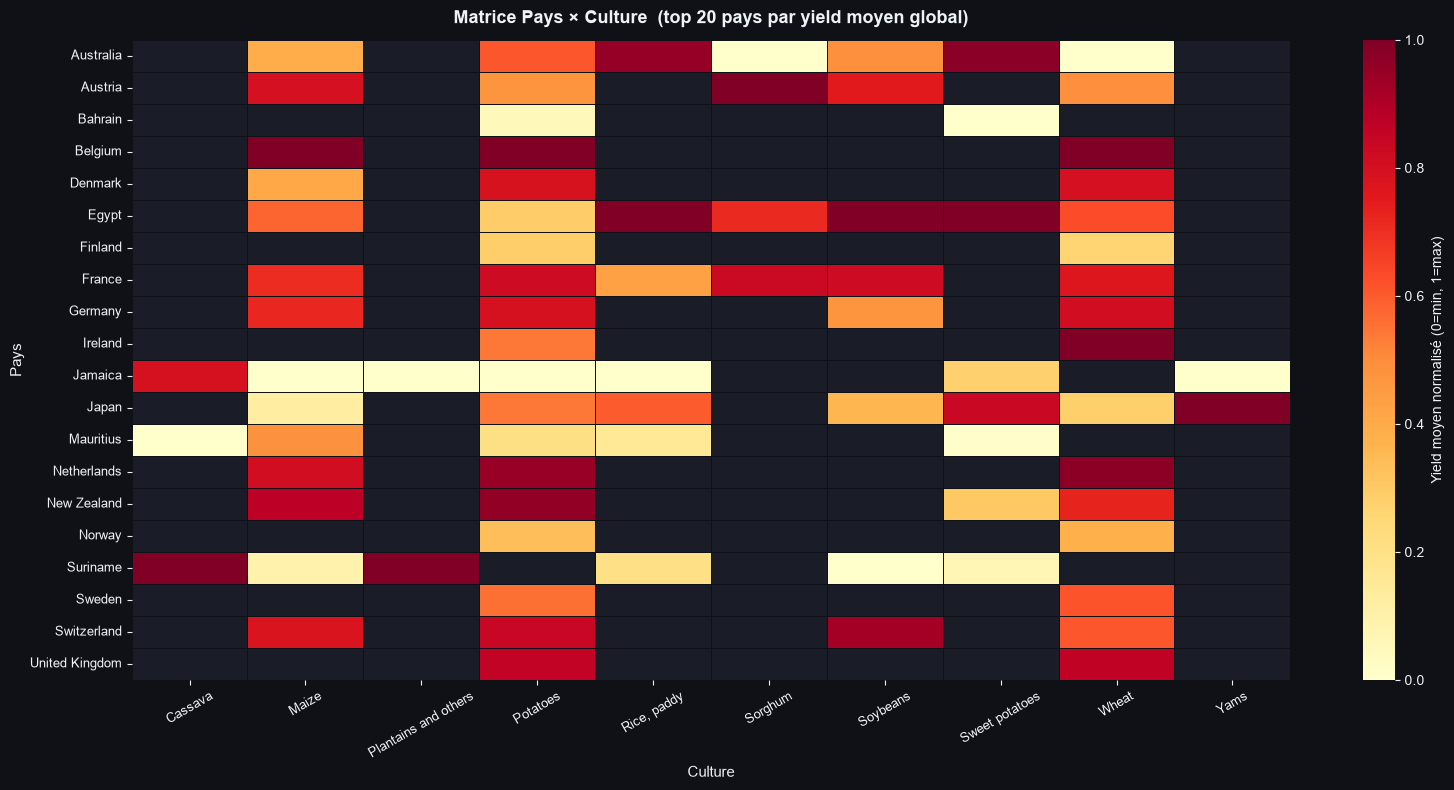

                     top_country     yield
crop                                      
Cassava                 Suriname  191282.0
Maize                    Belgium  115525.0
Plantains and others    Suriname  253967.0
Potatoes                 Belgium  448892.0
Rice, paddy                Egypt   89235.0
Sorghum                  Austria   63873.0
Soybeans                   Egypt   29355.0
Sweet potatoes             Egypt  261369.0
Wheat                    Belgium   84989.0
Yams                       Japan  211343.0


In [255]:
top_countries = (
    agri.groupby("country")["yield"].mean().sort_values(ascending=False).head(20).index
)
pivot = agri[agri["country"].isin(top_countries)].pivot_table(
    index="country", columns="crop", values="yield", aggfunc="mean"
)
# Normalisation par colonne pour comparer les cultures entre elles
pivot_norm = (pivot - pivot.min()) / (pivot.max() - pivot.min())

fig, ax = plt.subplots(figsize=(16, 8))
fig.patch.set_facecolor(BG_COLOR)

cmap = sns.color_palette("YlOrRd", as_cmap=True)
sns.heatmap(
    pivot_norm,
    ax=ax,
    cmap=cmap,
    annot=False,
    linewidths=0.5,
    linecolor="#0f1117",
    cbar_kws={"label": "Yield moyen normalisé (0=min, 1=max)"},
)

ax.set_title(
    "Matrice Pays × Culture  (top 20 pays par yield moyen global)",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
ax.set_xlabel("Culture", fontsize=11)
ax.set_ylabel("Pays", fontsize=11)
ax.tick_params(axis="x", rotation=30, labelsize=9)
ax.tick_params(axis="y", labelsize=9)

plt.tight_layout()
plt.savefig(
    PLOTS / "fig_country_crop_heatmap.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR,
)
plt.show()

# Pays en tête pour chaque culture, parmi ces 20 pays au yield global le plus élevé
top_per_crop = pivot.idxmax().rename("top_country")
print(pd.concat([top_per_crop, pivot.max().rename("yield")], axis=1).round(0))


**Lecture** : parmi ces 20 pays au yield global le plus élevé, la Belgique arrive en tête pour `Potatoes`, `Wheat` et `Maize` (Europe de l'Ouest), et le Suriname pour `Cassava` et `Plantains and others` (Amérique du Sud tropicale) — cohérent avec la spécialisation géographique observée plus haut. Exception notable : le pays en tête pour `Yams` est le Japon, pas un pays tropical — un effet d'échantillon, puisque seuls 21 pays produisent des yams dans ce jeu de données et que peu figurent aussi dans ce top 20 par yield global.

# MODELLING


## SUBSETS

### Holdout Test Set

In [329]:
# Rows
agri = agri.sort_values(by=["year", "country", "crop"]).reset_index(drop=True)

train_mask = agri["year"] < TEST_YEAR_START
test_mask = agri["year"] >= TEST_YEAR_START

df_train, df_test = agri[train_mask], agri[test_mask]

# Columns
inputs_train, targets_train = df_train.drop(columns=TARGET), df_train[TARGET]
inputs_test, targets_test = df_test.drop(columns=TARGET), df_test[TARGET]

print(
    f"[TRAIN] Inputs: {inputs_train.shape} (Years {inputs_train.year.min()}-{inputs_train.year.max()})"
)
print(
    f"[TEST]  Inputs: {inputs_test.shape} (Years {inputs_test.year.min()}-{inputs_test.year.max()})"
)

[TRAIN] Inputs: (23233, 6) (Years 1990-2009)
[TEST]  Inputs: (5009, 6) (Years 2010-2013)


### CV splits

In [330]:
# 1. Fenêtre d'entraînement FIXE (5 ans, cf. section WINDOW OPTIMUM) et test de 4 ans.
start_year = inputs_train["year"].min()
window = 5
step = 4
SPLITS = 3

custom_cv_splits = []

for i in range(SPLITS):
    # Train : fenêtre glissante de taille FIXE (ne s'agrandit plus au fil des folds).
    train_start_year = start_year + i * step
    train_end_year = train_start_year + window

    # Test : les 4 années immédiatement suivantes.
    test_end_year = train_end_year + step

    # Récupération des index
    train_idx = inputs_train[
        (inputs_train["year"] >= train_start_year)
        & (inputs_train["year"] < train_end_year)
    ].index
    test_idx = inputs_train[
        (inputs_train["year"] >= train_end_year)
        & (inputs_train["year"] < test_end_year)
    ].index

    custom_cv_splits.append((train_idx, test_idx))

# 2. Affichage de contrôle
print(f"SPLITS GLISSANTS À FENÊTRE FIXE ({window} ans Train -> {step} ans Test) :")
print("─" * 65)
for fold, (tr_idx, te_idx) in enumerate(custom_cv_splits):
    tr_yrs = inputs_train.loc[tr_idx, "year"]
    te_yrs = inputs_train.loc[te_idx, "year"]

    if te_yrs.empty:
        print(
            f"Fold {fold + 1} | Train: {tr_yrs.min()}-{tr_yrs.max()} ({len(tr_idx):>5} rows) | Test: EMPTY"
        )
    else:
        print(
            f"Fold {fold + 1} | Train: {tr_yrs.min()}-{tr_yrs.max()} ({len(tr_idx):>5} rows) "
            f"| Test: {te_yrs.min()}-{te_yrs.max()} ({len(te_idx):>5} rows)"
        )

SPLITS GLISSANTS À FENÊTRE FIXE (5 ans Train -> 4 ans Test) :
─────────────────────────────────────────────────────────────────
Fold 1 | Train: 1990-1994 ( 5991 rows) | Test: 1995-1998 ( 4892 rows)
Fold 2 | Train: 1994-1998 ( 6113 rows) | Test: 1999-2002 ( 4910 rows)
Fold 3 | Train: 1998-2002 ( 6134 rows) | Test: 2004-2006 ( 3712 rows)


### Assertions

In [331]:
# Assertions on raw inputs
assert inputs_train.year.max() < inputs_test.year.min(), (
    "Inputs train should be before inputs test"
)

## PREPROCESSING


### Transformer


In [322]:
class AgriFeatureEngineerLinear(sk.base.BaseEstimator, sk.base.TransformerMixin):
    def __init__(self):
        self.crop_opt_temps = {
            "Wheat": 15,
            "Rice, paddy": 28,
            "Maize": 22,
            "Potatoes": 17,
            "Soybeans": 22,
            "Sorghum": 28,
            "Cassava": 27,
            "Sweet potatoes": 25,
            "Plantains and others": 26,
            "Yams": 25,
        }

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X["log_pesticides"] = np.log1p(X["pest"])
        X["log_rainfall"] = np.log1p(X["rain"])
        X["rain_temp_interaction"] = X["rain"] * X["temp"]
        X["temp_deviation"] = X.apply(
            lambda r: abs(r["temp"] - self.crop_opt_temps.get(r["crop"], 22)),
            axis=1,
        )
        X["rain_efficiency"] = X["rain"] / (
            X["temp"] + 10
        )  # indice d'Aridité de De Martonne.
        return X

In [323]:
class AgriFeatureEngineer(sk.base.BaseEstimator, sk.base.TransformerMixin):
    def __init__(self):
        self.crop_opt_temps = {
            "Wheat": 15,
            "Rice, paddy": 28,
            "Maize": 22,
            "Potatoes": 17,
            "Soybeans": 22,
            "Sorghum": 28,
            "Cassava": 27,
            "Sweet potatoes": 25,
            "Plantains and others": 26,
            "Yams": 25,
        }

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X["rain_temp_interaction"] = X["rain"] * X["temp"]
        X["temp_deviation"] = X.apply(
            lambda r: abs(r["temp"] - self.crop_opt_temps.get(r["crop"], 22)),
            axis=1,
        )
        X["rain_efficiency"] = X["rain"] / (
            X["temp"] + 10
        )  # indice d'Aridité de De Martonne.
        return X

### Preprocessor


In [324]:
NUMERICAL_COLS_LINEAR = [
    "year",
    "temp",
    "log_pesticides",
    "log_rainfall",
    "temp_deviation",
    "rain_temp_interaction",
    "rain_efficiency",
]

NUMERICAL_COLS_TREE = [
    "year",
    "temp",
    "pest",
    "rain",
    "temp_deviation",
    "rain_temp_interaction",
    "rain_efficiency",
]

CATEGORICAL_COLS = ["country", "crop"]

# Preprocessor Linéaire
preprocessor_linear = pipeline.Pipeline(
    steps=[
        ("fe", AgriFeatureEngineerLinear()),
        (
            "encode_scale",
            compose.ColumnTransformer(
                transformers=[
                    ("num", preprocessing.StandardScaler(), NUMERICAL_COLS_LINEAR),
                    (
                        "cat",
                        preprocessing.OneHotEncoder(
                            handle_unknown="ignore", sparse_output=False
                        ),
                        CATEGORICAL_COLS,
                    ),
                ]
            ),
        ),
    ]
)


# Preprocessor Arbres
preprocessor_tree = pipeline.Pipeline(
    steps=[
        ("fe", AgriFeatureEngineer()),
        (
            "encode_scale",
            compose.ColumnTransformer(
                transformers=[
                    ("num", "passthrough", NUMERICAL_COLS_TREE),
                    (
                        "cat",
                        preprocessing.OrdinalEncoder(
                            handle_unknown="use_encoded_value", unknown_value=-1
                        ),
                        CATEGORICAL_COLS,
                    ),
                ]
            ),
        ),
    ]
)

preprocessor_tree_target = pipeline.Pipeline(
    steps=[
        ("fe", AgriFeatureEngineer()),
        (
            "encode_scale",
            compose.ColumnTransformer(
                transformers=[
                    ("num", "passthrough", NUMERICAL_COLS_TREE),
                    (
                        "target_cat",
                        preprocessing.TargetEncoder(
                            smooth="auto",  # shrinkage vers la moyenne globale pour les catégories rares
                            cv=5,  # cross-fitting par défaut : la ligne courante ne fuite pas dans son propre encodage
                            target_type="continuous",
                            random_state=RANDOM,
                        ),
                        CATEGORICAL_COLS,
                    ),
                ]
            ),
        ),
    ]
)

## BENCHMARK


### Baselines


In [325]:
baselines = {
    "Naive Mean": dummy.DummyRegressor(strategy="mean"),
    "Linear Regression": linear_model.LinearRegression(),
    "Ridge Regression": linear_model.Ridge(alpha=1.0),
}

baseline_results = {}
for name, model in baselines.items():
    pipe = pipeline.Pipeline(
        steps=[
            ("preprocessor", preprocessor_linear),
            ("regressor", model),
        ]
    )
    scores = model_selection.cross_val_score(
        pipe,
        inputs_train,
        targets_train,
        cv=custom_cv_splits,
        scoring=SCORING,
    )
    baseline_results[name] = -scores.mean()

print("🏁 BASELINE RESULTS (CV RMSE)")
print("═" * 40)
for name, rmse in baseline_results.items():
    bar = "█" * int(rmse // 5000)
    print(f"{name:<22} RMSE: {rmse:>10,.2f}  {bar}")

🏁 BASELINE RESULTS (CV RMSE)
════════════════════════════════════════
Naive Mean             RMSE:  83,314.52  ████████████████
Linear Regression      RMSE:  40,428.95  ████████
Ridge Regression       RMSE:  40,565.72  ████████


### Tree Ensembles without target encoding

In [326]:
tree_models = {
    "Random Forest": ensemble.RandomForestRegressor(
        n_estimators=100, random_state=RANDOM, n_jobs=-1
    ),
    "XGBoost": xgb.XGBRegressor(
        n_estimators=100, learning_rate=0.1, random_state=RANDOM, n_jobs=-1
    ),
}

tree_results = {}
for name, model in tree_models.items():
    pipe = pipeline.Pipeline(
        steps=[
            ("preprocessor", preprocessor_tree),
            ("regressor", model),
        ]
    )
    scores = model_selection.cross_val_score(
        pipe,
        inputs_train,
        targets_train,
        cv=custom_cv_splits,
        scoring=SCORING,
    )
    tree_results[name] = -scores.mean()

print("🌲 TREE MODELS RESULTS (CV RMSE)")
print("═" * 40)
for name, rmse in tree_results.items():
    bar = "█" * int(rmse // 5000)
    print(f"{name:<22} RMSE: {rmse:>10,.2f}  {bar}")

🌲 TREE MODELS RESULTS (CV RMSE)
════════════════════════════════════════
Random Forest          RMSE:  26,240.90  █████
XGBoost                RMSE:  23,496.66  ████


### Tree Ensembles with target encoding

In [327]:
tree_models = {
    "Random Forest": ensemble.RandomForestRegressor(
        n_estimators=100, random_state=RANDOM, n_jobs=-1
    ),
    "XGBoost": xgb.XGBRegressor(
        n_estimators=100, learning_rate=0.1, random_state=RANDOM, n_jobs=-1
    ),
}

tree_target_results = {}
for name, model in tree_models.items():
    pipe = pipeline.Pipeline(
        steps=[
            ("preprocessor", preprocessor_tree_target),
            ("regressor", model),
        ]
    )
    scores = model_selection.cross_val_score(
        pipe,
        inputs_train,
        targets_train,
        cv=custom_cv_splits,
        scoring=SCORING,
    )
    tree_target_results[name] = -scores.mean()

print("🌲 TREE MODELS RESULTS (CV RMSE)")
print("═" * 40)
for name, rmse in tree_target_results.items():
    bar = "█" * int(rmse // 5000)
    print(f"{name:<22} RMSE: {rmse:>10,.2f}  {bar}")

🌲 TREE MODELS RESULTS (CV RMSE)
════════════════════════════════════════
Random Forest          RMSE:  18,632.49  ███
XGBoost                RMSE:  19,843.22  ███


### Comparison

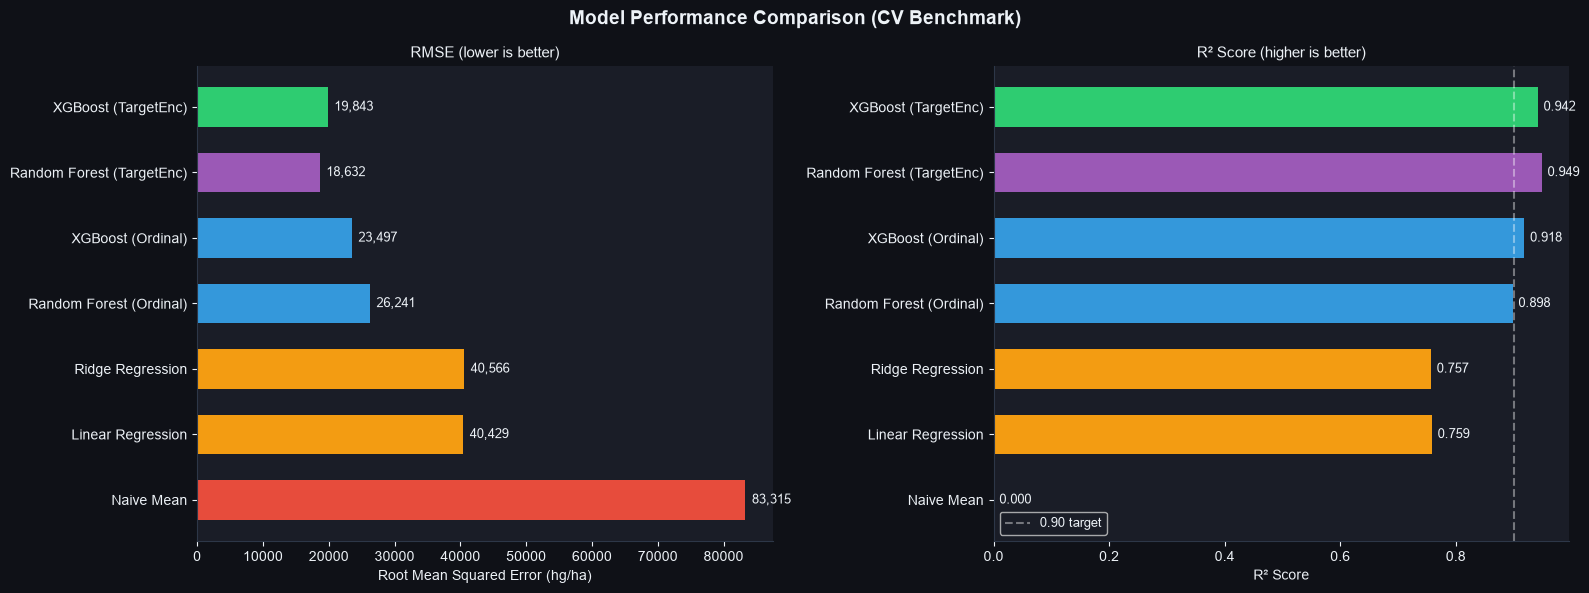


📈 Improvement over Naive Baseline:
─────────────────────────────────────────────
   Linear Regression               +51.5%
   Ridge Regression                +51.3%
   Random Forest (Ordinal)         +68.5%
   XGBoost (Ordinal)               +71.8%
   Random Forest (TargetEnc)       +77.6%
   XGBoost (TargetEnc)             +76.2%


In [328]:
# 1. Calcul du R² pour chaque score CV RMSE
# R²_approx = 1 - (MSE / VAR_Y).
var_y = np.var(targets_train)

all_model_results = {}

# Récupération des résultats Baselines
for name, rmse in baseline_results.items():
    mse = rmse**2
    r2 = max(0.0, 1.0 - (mse / var_y))
    all_model_results[name] = {"rmse": rmse, "r2": r2}

# Récupération des résultats Tree Ensembles (sans Target Encoding)
for name, rmse in tree_results.items():
    mse = rmse**2
    r2 = max(0.0, 1.0 - (mse / var_y))
    all_model_results[f"{name} (Ordinal)"] = {"rmse": rmse, "r2": r2}

# Récupération des résultats Tree Ensembles (avec Target Encoding)
for name, rmse in tree_target_results.items():
    mse = rmse**2
    r2 = max(0.0, 1.0 - (mse / var_y))
    all_model_results[f"{name} (TargetEnc)"] = {"rmse": rmse, "r2": r2}

# 2. Préparation des données pour le graphe
names = list(all_model_results.keys())
rmses = [all_model_results[n]["rmse"] for n in names]
r2s = [all_model_results[n]["r2"] for n in names]

# Palette de couleurs adaptée
colors = [
    "#e74c3c",  # Naive Mean (Rouge)
    "#f39c12",  # Linear (Orange)
    "#f39c12",  # Ridge (Orange)
    "#3498db",  # RF Ordinal (Bleu)
    "#3498db",  # XGB Ordinal (Bleu)
    "#9b59b6",  # RF TargetEnc (Violet)
    ACCENT,  # XGB TargetEnc (Vert Vertueux / Gagnant)
]

# 3. Tracé des sous-graphiques
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG_COLOR)
fig.suptitle(
    "Model Performance Comparison (CV Benchmark)", fontsize=14, fontweight="bold"
)

# Graphique 1 : RMSE (lower is better)
bars = axes[0].barh(names, rmses, color=colors, edgecolor="none", height=0.6)
for bar, val in zip(bars, rmses):
    axes[0].text(
        val + 1000,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,.0f}",
        va="center",
        fontsize=9,
    )
axes[0].set_title("RMSE (lower is better)", fontsize=11)
axes[0].set_xlabel("Root Mean Squared Error (hg/ha)")

# Graphique 2 : R² (higher is better)
bars2 = axes[1].barh(names, r2s, color=colors, edgecolor="none", height=0.6)
for bar, val in zip(bars2, r2s):
    axes[1].text(
        val + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va="center",
        fontsize=9,
    )
axes[1].set_title("R² Score (higher is better)", fontsize=11)
axes[1].set_xlabel("R² Score")
axes[1].axvline(0.9, color="white", linestyle="--", alpha=0.4, label="0.90 target")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(
    PLOTS / "fig_model_comparison.png", dpi=150, bbox_inches="tight", facecolor=BG_COLOR
)
plt.show()

# 4. Affichage du pourcentage d'amélioration par rapport à la Naive Baseline
naive_rmse = all_model_results["Naive Mean"]["rmse"]
print("\n📈 Improvement over Naive Baseline:")
print("─" * 45)
for name, res in all_model_results.items():
    if name == "Naive Mean":
        continue
    impr = ((naive_rmse - res["rmse"]) / naive_rmse) * 100
    print(f"   {name:<30}  {impr:+.1f}%")

## WINDOW OPTIMUM

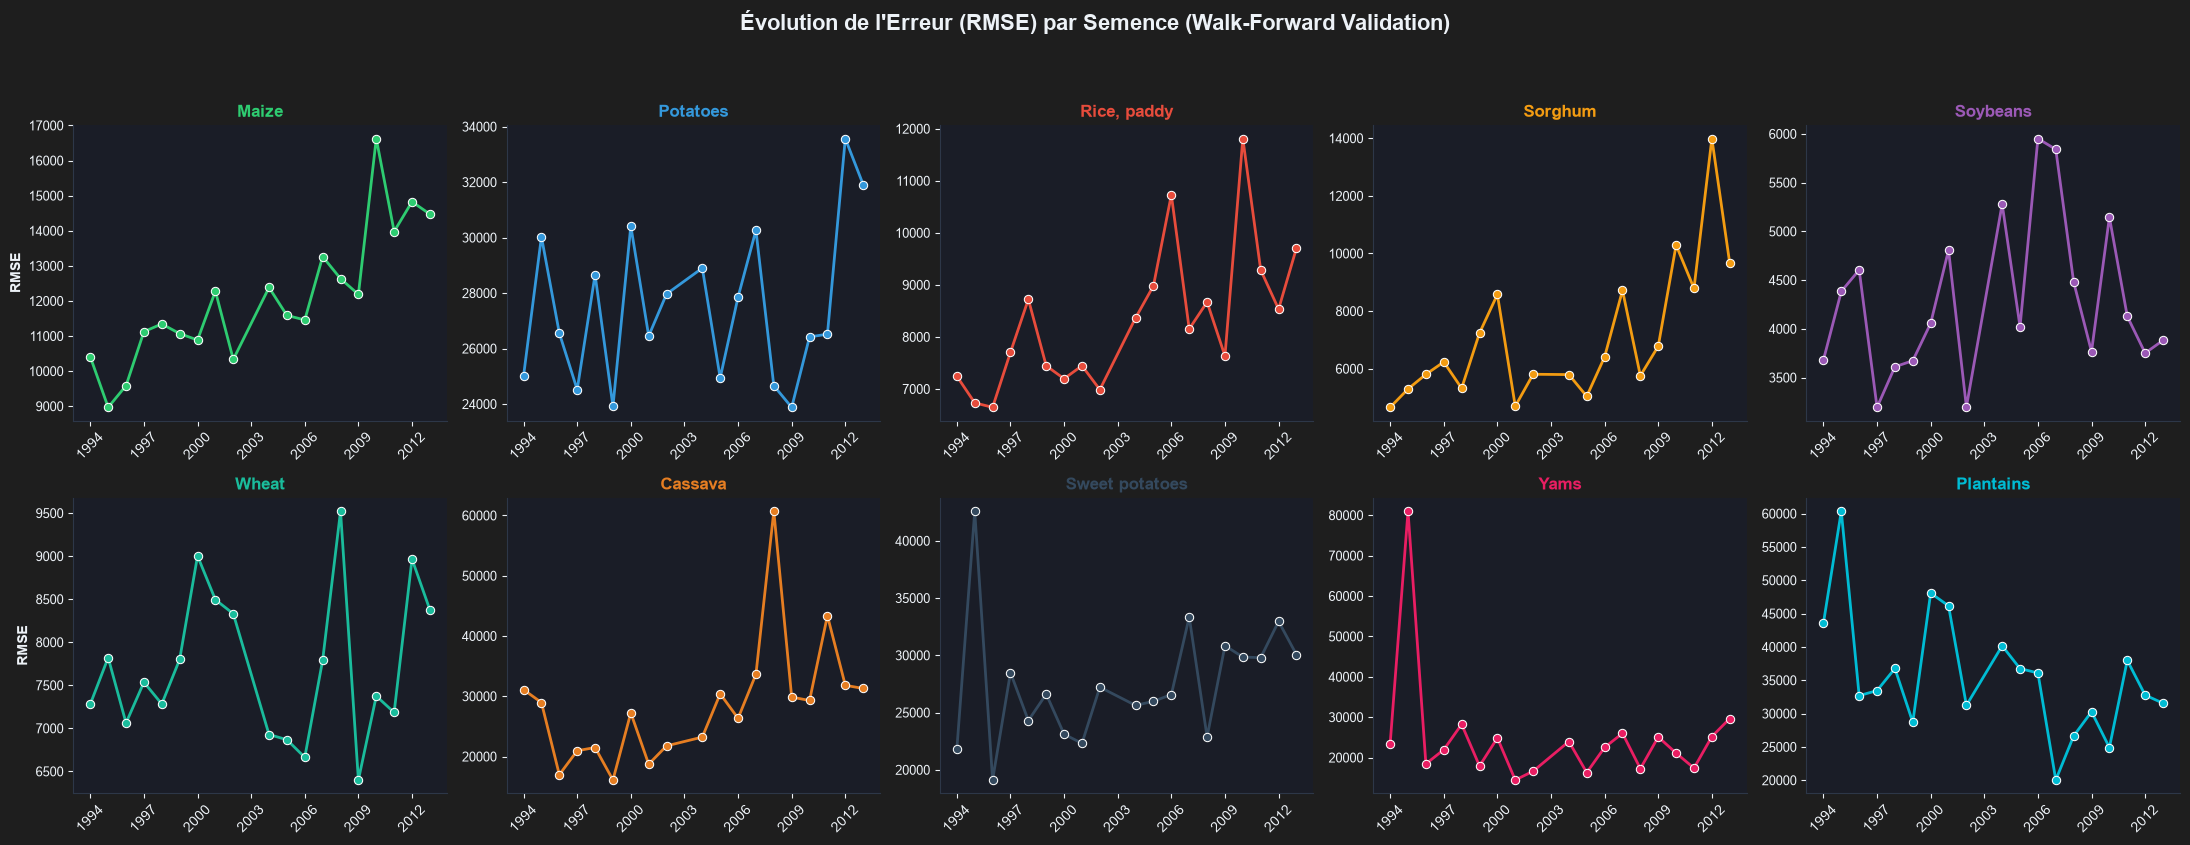

In [50]:
# ==========================================
# 1. CALCUL DES ERREURS PAR CULTURE
# ==========================================
crops = agri["crop"].unique()
results_per_crop = []

start_year = agri["year"].min()
max_year = agri["year"].max()
window_size = 4

# Définition du pipeline
model = pipeline.Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree_target),
        (
            "regressor",
            xgb.XGBRegressor(
                n_estimators=100, learning_rate=0.1, random_state=RANDOM, n_jobs=-1
            ),
        ),
    ]
)

# On boucle sur chaque année cible
for target_year in range(start_year + window_size, max_year + 1):
    train_start = target_year - window_size
    train_end = target_year

    train_mask = (agri["year"] >= train_start) & (agri["year"] < train_end)
    test_mask = agri["year"] == target_year

    if not test_mask.any() or not train_mask.any():
        continue

    X_train, y_train = agri[train_mask].drop(columns=TARGET), agri[train_mask][TARGET]
    X_test, y_test = agri[test_mask].drop(columns=TARGET), agri[test_mask][TARGET]

    # Entraînement global (sur toutes les semences)
    model.fit(X_train, y_train)

    # Prédiction et évaluation isolée PAR culture
    for crop in crops:
        crop_mask = X_test["crop"] == crop
        if not crop_mask.any():
            continue

        X_test_crop = X_test[crop_mask]
        y_test_crop = y_test[crop_mask]

        preds_crop = model.predict(X_test_crop)
        rmse_crop = metrics.root_mean_squared_error(y_test_crop, preds_crop)

        results_per_crop.append({"year": target_year, "Crop": crop, "RMSE": rmse_crop})

df_crop_errors = pd.DataFrame(results_per_crop)

# ==========================================
# 2. AFFICHAGE DE LA GRILLE (FAÇON HEATMAP)
# ==========================================
fig, axes = plt.subplots(2, 5, figsize=(22, 8), sharex=True)
axes = axes.flatten()

fig.suptitle(
    "Évolution de l'Erreur (RMSE) par Semence (Walk-Forward Validation)",
    fontsize=16,
    fontweight="bold",
    y=1.05,
    color=TEXT_COLOR,
)
fig.patch.set_facecolor(BG_COLOR)

# Années pour l'axe X (1 année sur 3)
min_yr = df_crop_errors["year"].min()
max_yr = df_crop_errors["year"].max()
x_ticks_3_years = list(range(min_yr, max_yr + 1, 3))

for idx, crop in enumerate(crops):
    ax = axes[idx]
    crop_data = df_crop_errors[df_crop_errors["Crop"] == crop]
    color = PALETTE[idx % len(PALETTE)]

    # Tracé de la courbe
    sns.lineplot(
        data=crop_data, x="year", y="RMSE", ax=ax, color=color, marker="o", linewidth=2
    )

    # Esthétique des Cards
    ax.set_facecolor(CARD_COLOR)
    ax.set_title(
        crop.replace(" and others", ""), fontsize=12, fontweight="bold", color=color
    )

    # Configuration de l'axe X (1 année sur 3)
    ax.set_xticks(x_ticks_3_years)
    ax.tick_params(
        axis="x", colors=TEXT_COLOR, labelsize=10, rotation=45, labelbottom=True
    )
    ax.tick_params(axis="y", colors=TEXT_COLOR, labelsize=9)

    # Noms des axes
    ax.set_xlabel("")
    if idx % 5 == 0:
        ax.set_ylabel("RMSE", color=TEXT_COLOR, fontweight="bold")
    else:
        ax.set_ylabel("")

    # Finitions des bordures
    for spine in ax.spines.values():
        spine.set_edgecolor("#2d3748")

plt.tight_layout()
plt.show()

,Fenetre,Periode_Train,Nb_Lignes_Train,Holdout_RMSE
0,2,2 ans (2008-2009),2486,26454.355469
1,3,3 ans (2007-2009),3728,24186.134766
2,4,4 ans (2006-2009),4971,23842.089844
3,5,5 ans (2005-2009),6206,22940.089844
4,6,6 ans (2004-2009),7440,23132.437500
5,7,7 ans (2003-2009),7440,23132.437500
6,8,8 ans (2002-2009),8668,23450.646484
7,9,9 ans (2001-2009),9897,23100.800781
8,10,10 ans (2000-2009),11127,23876.689453
9,11,11 ans (1999-2009),12350,24091.357422


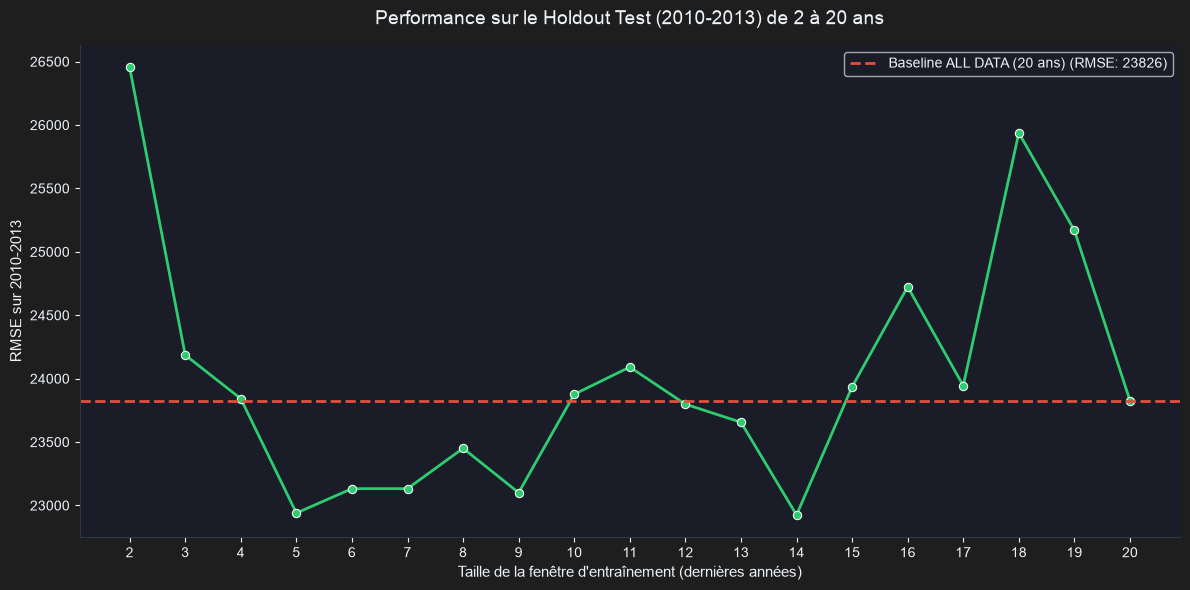

In [51]:
import matplotlib.ticker as mticker

# Définition du pipeline
model = pipeline.Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree_target),
        (
            "regressor",
            xgb.XGBRegressor(
                n_estimators=100, learning_rate=0.1, random_state=RANDOM, n_jobs=-1
            ),
        ),
    ]
)

# Calcul dynamique des bornes
train_min_year = inputs_train["year"].min()
train_max_year = inputs_train["year"].max()
test_start_year = inputs_test["year"].min()

# La fenêtre maximale correspond à l'intégralité de l'historique (ex: 2010 - 1990 = 20 ans)
max_window = test_start_year - train_min_year
windows_to_test = list(range(2, max_window + 1))

results_holdout = []

for w in windows_to_test:
    # Calcul de l'année de coupe
    min_year_in_window = test_start_year - w
    mask = inputs_train["year"] >= min_year_in_window

    X_tr = inputs_train[mask]
    y_tr = targets_train[mask]
    label = f"{w} ans ({min_year_in_window}-{train_max_year})"

    # Entraînement
    model.fit(X_tr, y_tr)

    # Prédiction globale sur le Holdout Test (2010-2013)
    preds = model.predict(inputs_test)

    # Calcul du RMSE
    rmse = metrics.root_mean_squared_error(targets_test, preds)

    results_holdout.append(
        {
            "Fenetre": w,
            "Periode_Train": label,
            "Nb_Lignes_Train": len(X_tr),
            "Holdout_RMSE": rmse,
        }
    )

# 1. Affichage du tableau de résultats
df_holdout_results = pd.DataFrame(results_holdout)
display(df_holdout_results)

# 2. Graphique comparatif complet
plt.figure(figsize=(12, 6), facecolor=BG_COLOR)
ax = plt.gca()
ax.set_facecolor(CARD_COLOR)

# Le RMSE "ALL DATA" correspond à la fenêtre maximale (le dernier point)
rmse_all = df_holdout_results[df_holdout_results["Fenetre"] == max_window][
    "Holdout_RMSE"
].values[0]

sns.lineplot(
    data=df_holdout_results,
    x="Fenetre",
    y="Holdout_RMSE",
    marker="o",
    color=ACCENT,
    linewidth=2,
    ax=ax,
)

# Ligne horizontale rouge de référence (Entraînement complet = max_window)
ax.axhline(
    rmse_all,
    color="#e74c3c",
    linestyle="--",
    linewidth=2,
    label=f"Baseline ALL DATA ({max_window} ans) (RMSE: {rmse_all:.0f})",
)

# Esthétique
ax.set_title(
    "Performance sur le Holdout Test (2010-2013) de 2 à 20 ans",
    color=TEXT_COLOR,
    fontsize=14,
    pad=15,
)
ax.set_xlabel(
    "Taille de la fenêtre d'entraînement (dernières années)",
    color=TEXT_COLOR,
    fontsize=11,
)
ax.set_ylabel("RMSE sur 2010-2013", color=TEXT_COLOR, fontsize=11)

# On force l'axe X à afficher chaque palier de 1 an
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.tick_params(colors=TEXT_COLOR)

for spine in ax.spines.values():
    spine.set_edgecolor("#2d3748")

plt.legend(facecolor=CARD_COLOR, labelcolor=TEXT_COLOR)
plt.tight_layout()
plt.show()

Test des fenêtres d'entraînement:   0%|          | 0/19 [00:00<?, ?it/s]

Test des fenêtres d'entraînement: 100%|██████████| 19/19 [00:45<00:00,  2.38s/it]


,Fenetre,RMSE_Moyen,Ecart_Type_RMSE,Nb_Folds
0,2,23883.293997,2500.586074,19
1,3,21157.439019,1869.298300,18
2,4,21248.500000,2180.532361,17
3,5,20652.462524,1306.206328,16
4,6,20784.127995,1355.742020,15
5,7,21031.236747,1278.792493,14
6,8,21360.798528,1300.070661,13
7,9,21085.010579,1403.314934,12
8,10,21208.704368,1576.868646,11
9,11,21223.025195,1584.479507,10


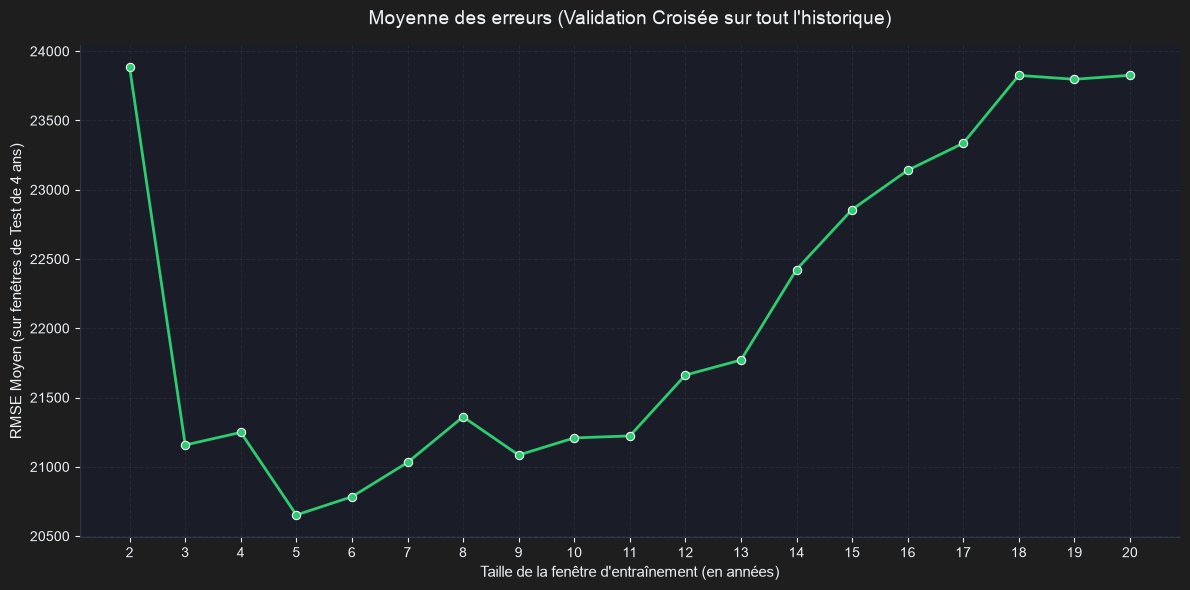

In [52]:
import numpy as np
from tqdm.auto import tqdm

windows_to_test = list(range(2, 21))
results_cv = []

# Bornes du dataset global (1990 à 2013)
min_year = agri["year"].min()
max_year = agri["year"].max()
test_duration = 4

# La dernière année de test possible commence en 2010 (pour prédire 2010, 2011, 2012, 2013)
last_possible_test_start = max_year - test_duration + 1

for w in tqdm(windows_to_test, desc="Test des fenêtres d'entraînement"):
    rmses_for_w = []

    # On fait glisser l'année de début du test
    for test_start_year in range(min_year + w, last_possible_test_start + 1):
        test_end_year = test_start_year + test_duration
        train_start_year = test_start_year - w

        # Filtres temporels stricts pour éviter tout Leakage
        train_mask = (agri["year"] >= train_start_year) & (
            agri["year"] < test_start_year
        )
        test_mask = (agri["year"] >= test_start_year) & (agri["year"] < test_end_year)

        if not train_mask.any() or not test_mask.any():
            continue

        X_tr, y_tr = agri[train_mask].drop(columns=TARGET), agri[train_mask][TARGET]
        X_te, y_te = agri[test_mask].drop(columns=TARGET), agri[test_mask][TARGET]

        # Entraînement et prédiction
        model.fit(X_tr, y_tr)
        preds = model.predict(X_te)

        rmse = metrics.root_mean_squared_error(y_te, preds)
        rmses_for_w.append(rmse)

    # On stocke la moyenne de toutes les expériences pour la fenêtre 'w'
    if len(rmses_for_w) > 0:
        results_cv.append(
            {
                "Fenetre": w,
                "RMSE_Moyen": np.mean(rmses_for_w),
                "Ecart_Type_RMSE": np.std(rmses_for_w),
                "Nb_Folds": len(rmses_for_w),
            }
        )

# 1. Affichage des résultats
df_cv_results = pd.DataFrame(results_cv)
display(df_cv_results)

# 2. Graphique
plt.figure(figsize=(12, 6), facecolor=BG_COLOR)
ax = plt.gca()
ax.set_facecolor(CARD_COLOR)

sns.lineplot(
    data=df_cv_results,
    x="Fenetre",
    y="RMSE_Moyen",
    marker="o",
    color=ACCENT,
    linewidth=2,
    ax=ax,
)

# Esthétique
ax.set_title(
    "Moyenne des erreurs (Validation Croisée sur tout l'historique)",
    color=TEXT_COLOR,
    fontsize=14,
    pad=15,
)
ax.set_xlabel(
    "Taille de la fenêtre d'entraînement (en années)", color=TEXT_COLOR, fontsize=11
)
ax.set_ylabel(
    "RMSE Moyen (sur fenêtres de Test de 4 ans)", color=TEXT_COLOR, fontsize=11
)

ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.tick_params(colors=TEXT_COLOR)

for spine in ax.spines.values():
    spine.set_edgecolor("#2d3748")

plt.grid(color="#2d3748", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

**Lecture** : des trois diagnostics de cette section, seule la dernière cellule (`df_cv_results`, validation croisée glissante) donne une estimation fiable de la fenêtre optimale — elle moyenne le RMSE sur jusqu'à 19 folds répartis sur tout l'historique (1990-2013), avec un écart-type associé. Le RMSE moyen est minimal pour une fenêtre de **5 ans** (20 652 ± 1 306), nettement sous les 2 ans (23 883 ± 2 501), puis se dégrade progressivement jusqu'à 20 ans (23 826) — cohérent avec la dérive temporelle vue en exploration (les rendements progressent structurellement d'année en année, donc les vieilles données d'entraînement deviennent de moins en moins représentatives).

Le test sur holdout unique (`df_holdout_results`, cellule du milieu) est trop bruité pour trancher seul : il désigne 14 ans (22 925) comme optimum, quasiment à égalité avec 5 ans (22 940) — un artefact du fait qu'il n'évalue qu'une seule période de test (2010-2013) au lieu de la moyenner sur plusieurs folds comme `df_cv_results`.

**Conclusion** : mieux vaut entraîner sur une fenêtre glissante de 5 ans plutôt que sur tout l'historique. Cela remet en question le `step = 4` utilisé dans `custom_cv_splits` (section SUBSETS) : la fenêtre du pipeline final n'est pas alignée avec cet optimum et gagnerait à passer à 5 ans.

## TUNING

### Search

In [332]:
draft = pipeline.Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree_target),
        ("regressor", xgb.XGBRegressor()),
    ]
)

search = model_selection.RandomizedSearchCV(
    estimator=draft,
    cv=custom_cv_splits,
    param_distributions=PARAM_GRID_XGB,
    n_iter=N_ITER,
    scoring=SCORING,
    random_state=RANDOM,
    n_jobs=-1,
    verbose=0,
)

total_fits = N_ITER * len(custom_cv_splits)

with tqdm_joblib(desc="⚡ XGBoost RandomizedSearch", total=total_fits):
    search.fit(inputs_train, targets_train)

⚡ XGBoost RandomizedSearch:   0%|          | 0/60 [00:00<?, ?it/s]

### Results

In [333]:
results = pd.DataFrame(search.cv_results_)
results["mean_rmse"] = -results["mean_test_score"]

results.sort_values(by="rank_test_score").head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_regressor__subsample,param_regressor__n_estimators,param_regressor__max_depth,param_regressor__learning_rate,param_regressor__colsample_bytree,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,mean_rmse
12,4.368007,0.091311,0.110557,0.022714,0.8,500,10,0.03,1.0,"{'regressor__subsample': 0.8, 'regressor__n_es...",-17721.134766,-20562.857422,-17235.169922,-18506.387370,1467.615359,1,18506.387370
15,1.729901,0.046036,0.107215,0.035189,0.8,500,8,0.10,0.8,"{'regressor__subsample': 0.8, 'regressor__n_es...",-17771.578125,-20788.238281,-17291.701172,-18617.172526,1547.625139,2,18617.172526
8,1.332647,0.123415,0.106873,0.041807,0.8,150,10,0.10,0.8,"{'regressor__subsample': 0.8, 'regressor__n_es...",-18301.863281,-20812.630859,-17470.986328,-18861.826823,1420.520191,3,18861.826823
7,2.014421,0.081322,0.118243,0.019578,1.0,500,8,0.10,0.8,"{'regressor__subsample': 1.0, 'regressor__n_es...",-18025.845703,-21135.283203,-17629.085938,-18930.071615,1567.710260,4,18930.071615
6,0.743368,0.006059,0.072876,0.023009,0.8,150,8,0.10,1.0,"{'regressor__subsample': 0.8, 'regressor__n_es...",-18245.494141,-20931.740234,-17725.513672,-18967.582682,1404.998479,5,18967.582682


## TRAINING

### Final

In [334]:
final = search.best_estimator_
final

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('fe', ...), ('encode_scale', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set 

### Params

In [335]:
print(final.get_params())

{'memory': None, 'steps': [('preprocessor', Pipeline(steps=[('fe', AgriFeatureEngineer()),
                ('encode_scale',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['year', 'temp', 'pest',
                                                   'rain', 'temp_deviation',
                                                   'rain_temp_interaction',
                                                   'rain_efficiency']),
                                                 ('target_cat',
                                                  TargetEncoder(random_state=42,
                                                                target_type='continuous'),
                                                  ['country', 'crop'])]))])), ('regressor', XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_st

## INFERENCE

### Predictions

In [336]:
predictions = pd.Series(final.predict(inputs_test), index=inputs_test.index)
print(predictions.shape)
predictions.head()

(5009,)


23233     48478.238281
23234    204497.359375
23235     18072.998047
23236     35489.710938
23237     40405.535156
dtype: float32

### Statistics

In [337]:
predictions.describe()

count      5009.000000
mean      84312.062500
std       90060.015625
min        2033.302124
25%       24031.599609
50%       43358.214844
75%      114031.523438
max      466407.968750
dtype: float64

## EVALUATION

### Error analysis

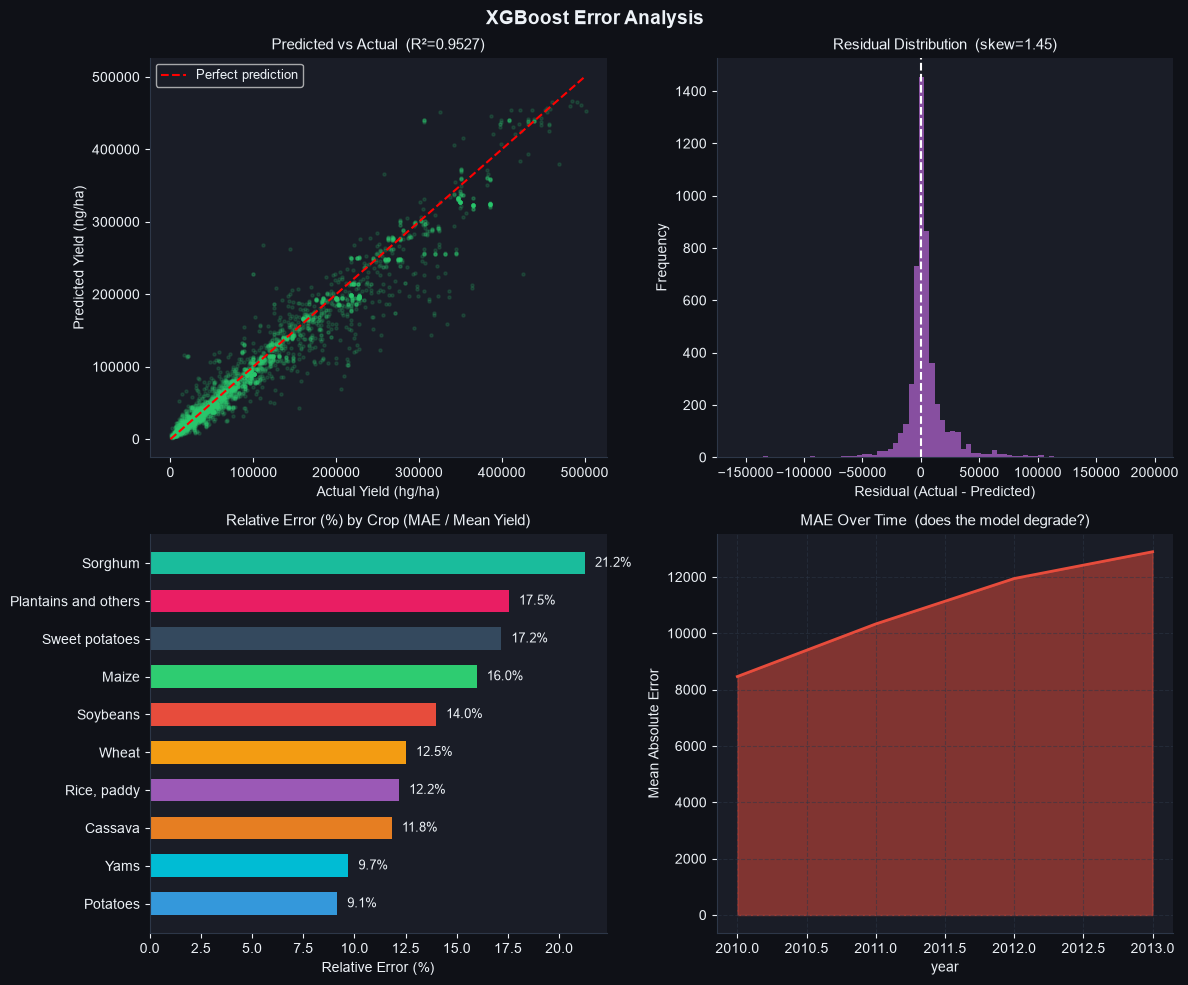

💡 Error Analysis Findings:
──────────────────────────────────────────────────
   Hardest crop to predict : Sorghum              (Error = 21.2%)
   Easiest crop to predict : Potatoes             (Error = 9.1%)
   Easiest crop to predict : Potatoes             (Error = 9.1%)
La dégradation progressive de la MAE au fil du temps (2010 ➔ 2013) illustre la dérive temporelle (Concept Drift).En production réel, cela prouve qu'il est indispensable de re-entraîner régulièrement le modèle chaque année avec les dernières données récoltées.


In [338]:
xgb_r2 = metrics.r2_score(targets_test, predictions)
errors = pd.DataFrame(
    {
        "actual": targets_test,
        "predicted": predictions,
        "residual": targets_test - predictions,
        "abs_error": np.abs(targets_test - predictions),
        "country": agri.loc[targets_test.index, "country"].values,
        "crop": agri.loc[targets_test.index, "crop"].values,
        "year": agri.loc[targets_test.index, "year"].values,
    }
)

unique_crops = errors["crop"].unique()
crop_colors = {crop: PALETTE[i % len(PALETTE)] for i, crop in enumerate(unique_crops)}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.patch.set_facecolor(BG_COLOR)
fig.suptitle("XGBoost Error Analysis", fontsize=14, fontweight="bold")

# 1. Predicted vs Actual
ax = axes[0, 0]
max_val = max(errors["actual"].max(), errors["predicted"].max())
ax.scatter(errors["actual"], errors["predicted"], alpha=0.15, s=5, color=ACCENT)
ax.plot([0, max_val], [0, max_val], "r--", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual Yield (hg/ha)")
ax.set_ylabel("Predicted Yield (hg/ha)")
ax.set_title(f"Predicted vs Actual  (R²={xgb_r2:.4f})", fontsize=11)
ax.legend(fontsize=9)

# 2. Residual distribution
ax = axes[0, 1]
ax.hist(errors["residual"], bins=80, color="#9b59b6", edgecolor="none", alpha=0.85)
ax.axvline(0, color="white", linestyle="--", linewidth=1.5)
ax.set_xlabel("Residual (Actual - Predicted)")
ax.set_ylabel("Frequency")
ax.set_title(
    f"Residual Distribution  (skew={errors['residual'].skew():.2f})", fontsize=11
)

# 3. Errors by crop
crop_stats = errors.groupby("crop").agg(
    mae=("abs_error", "mean"), mean_yield=("actual", "mean")
)
# Calcul du pourcentage d'erreur relative
crop_stats["relative_error_pct"] = (crop_stats["mae"] / crop_stats["mean_yield"]) * 100
crop_error_pct = crop_stats["relative_error_pct"].sort_values(ascending=True)

# Affichage graphique
ax = axes[1, 0]
crop_cols = [crop_colors.get(c, "#3498db") for c in crop_error_pct.index]
bars = ax.barh(
    crop_error_pct.index,
    crop_error_pct.values,
    color=crop_cols,
    edgecolor="none",
    height=0.6,
)
for bar, val in zip(bars, crop_error_pct.values):
    ax.text(
        val + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%",
        va="center",
        fontsize=9,
    )
ax.set_xlabel("Relative Error (%)")
ax.set_title("Relative Error (%) by Crop (MAE / Mean Yield)", fontsize=11)


# 4. Errors over time
ax = axes[1, 1]
yearly_err = errors.groupby("year")["abs_error"].mean()
ax.fill_between(yearly_err.index, yearly_err.values, alpha=0.5, color="#e74c3c")
ax.plot(yearly_err.index, yearly_err.values, color="#e74c3c", linewidth=2)
ax.set_xlabel("year")
ax.set_ylabel("Mean Absolute Error")
ax.set_title("MAE Over Time  (does the model degrade?)", fontsize=11)
ax.grid(True)

plt.tight_layout()
plt.savefig(
    PLOTS / "fig_error_analysis.png", dpi=150, bbox_inches="tight", facecolor=BG_COLOR
)
plt.show()


print("💡 Error Analysis Findings:")
hardest = crop_error_pct.index[-1]
easiest = crop_error_pct.index[0]
print("─" * 50)
print(
    f"   Hardest crop to predict : {hardest:<20} (Error = {crop_error_pct.iloc[-1]:.1f}%)"
)
print(
    f"   Easiest crop to predict : {easiest:<20} (Error = {crop_error_pct.iloc[0]:.1f}%)"
)

print(
    f"   Easiest crop to predict : {easiest:<20} (Error = {crop_error_pct.iloc[0]:.1f}%)"
)
print(
    "La dégradation progressive de la MAE au fil du temps (2010 ➔ 2013) illustre la dérive temporelle (Concept Drift).En production réel, cela prouve qu'il est indispensable de re-entraîner régulièrement le modèle chaque année avec les dernières données récoltées."
)

### Feature importances

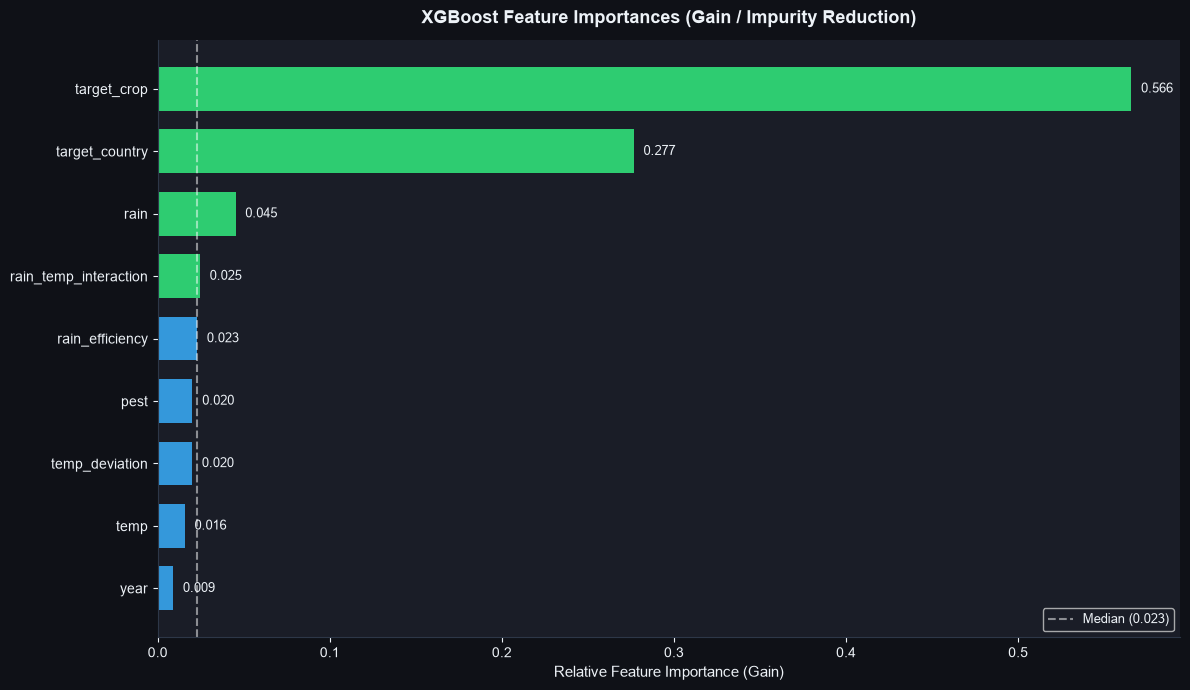


💡 Key Insight (XGBoost Feature Importance):
──────────────────────────────────────────────────
   • Most important feature : 'target_crop' (0.566)
   • Target-Encoded features (area & crop averages) play a key role.
   • Interaction features (rain_temp_interaction, rain_efficiency) contribute significantly.


In [339]:
# 1. Extraction de la meilleure pipeline et du modèle XGBoost entraîné
best_pipeline = search.best_estimator_
fitted_preprocessor = best_pipeline.named_steps["preprocessor"]
fitted_xgb = best_pipeline.named_steps["regressor"]

# 2. Récupération des noms exacts des colonnes transformées
feature_names = fitted_preprocessor.named_steps["encode_scale"].get_feature_names_out()

# Nettoyage des préfixes générés par ColumnTransformer (ex: 'num__Year' -> 'year')
clean_feature_names = [
    f.replace("num__", "")
    .replace("target_cat__", "target_")
    .replace("ordinal_cat__", "ord_")
    for f in feature_names
]

# 3. Extraction des importances et tri
importances = pd.Series(
    fitted_xgb.feature_importances_, index=clean_feature_names
).sort_values(ascending=True)

# 4. Tracé du graphique Matplotlib
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(BG_COLOR)

# Couleurs personnalisées (Vert ACCENT si au-dessus de la médiane, bleu sinon)
median_val = importances.median()
colors = [ACCENT if v > median_val else "#3498db" for v in importances.values]

bars = ax.barh(
    importances.index, importances.values, color=colors, edgecolor="none", height=0.7
)

# Annotations des valeurs sur les barres
for bar, val in zip(bars, importances.values):
    ax.text(
        val + max(importances.values) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va="center",
        fontsize=9,
    )

ax.axvline(
    median_val,
    color="white",
    linestyle="--",
    alpha=0.5,
    label=f"Median ({median_val:.3f})",
)
ax.set_title(
    "XGBoost Feature Importances (Gain / Impurity Reduction)",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
ax.set_xlabel("Relative Feature Importance (Gain)", fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(
    PLOTS / "fig_xgb_feature_importance.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR,
)
plt.show()

# Print Insights
top_feature = importances.index[-1]
print("\n💡 Key Insight (XGBoost Feature Importance):")
print("─" * 50)
print(f"   • Most important feature : '{top_feature}' ({importances.iloc[-1]:.3f})")
print("   • Target-Encoded features (area & crop averages) play a key role.")
print(
    "   • Interaction features (rain_temp_interaction, rain_efficiency) contribute significantly."
)